# Pipeline - Anemia por Conjuntiva

Ejecutamos el pipeline completo: auditoría anti-leakage, YOLO ROI, EfficientNet Baseline/Var1/Var2, métricas en test, curvas de entrenamiento y evidence pack.

Regla metodológica: train entrena, val calibra/elige umbral, test solo evalúa al final.

In [ ]:
# /02_semana5_pipeline_anemia_TESIS_FINAL.py
# Pipeline final Semana 5 / tesis: YOLO + ROI + EfficientNet + evidencia reproducible
# Objetivo: ejecutar experimentos comparables sin leakage

from __future__ import annotations

import json
import os
import platform
import shutil
import subprocess
import sys
import random
import time
import warnings
from contextlib import contextmanager
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import yaml
from PIL import Image, ImageDraw
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

try:
    from ultralytics import YOLO
except Exception as exc:  # noqa: BLE001
    YOLO = None
    _YOLO_IMPORT_ERROR = exc
else:
    _YOLO_IMPORT_ERROR = None

In [2]:
# =============================================================================
# 1) CONFIGURACIÓN ÚNICA DEL PROYECTO

In [3]:
# =============================================================================

@dataclass
class PipelineConfig:
    """
    Configuración centralizada.

    Estado correcto para tu caso actual:
    - usa data_clean.yaml, NO data.yaml;
    - modo rápido activado para validar el pipeline completo;
    - falla si detecta leakage por imagen base;
    - usa batch YOLO conservador para GPU de 6 GB aprox.

    Cuando entrenes de verdad:
    - cambia quick_mode=False;
    - sube yolo_epochs_real / classifier_epochs_real;
    - NO cambies data_clean.yaml por data.yaml.
    """

    project_dir: str = "."
    data_yaml: str = "data_clean.yaml"
    artifact_dir: str = "artifacts/week5_pipeline"

    seed: int = 42
    quick_mode: bool = True

    # Seguridad experimental.
    # Si esto está en True, el pipeline se detiene si encuentra leakage.
    fail_on_leakage: bool = True

    # Obliga a usar data_clean.yaml para no volver al split contaminado.
    # Desactívalo solo si sabes exactamente lo que haces.
    require_clean_yaml: bool = True

    # Seguridad de entorno.
    # En tu caso debe apuntar a: <proyecto>/.venv/Scripts/python.exe
    require_project_venv: bool = True
    expected_venv_dirname: str = ".venv"

    # CUDA no es obligatoria para que el pipeline funcione, pero sí recomendable.
    # Déjalo False para smoke test. Cámbialo a True antes de entrenamiento real si quieres bloquear CPU.
    require_cuda: bool = False

    # Ejecución
    run_train_yolo: bool = True
    run_train_baseline_full: bool = True
    run_train_roi_gt: bool = True
    run_yolo_e2e_eval: bool = True

    # Si run_train_* es False, se intentan cargar estos pesos.
    yolo_weights_path: str = "runs/detect/week5_yolo_quick/weights/best.pt"
    baseline_weights_path: str = "artifacts/week5_pipeline/baseline_full/best.pt"
    roi_gt_weights_path: str = "artifacts/week5_pipeline/roi_gt/best.pt"

    # Entrenamiento rápido vs real
    yolo_epochs_quick: int = 1
    yolo_epochs_real: int = 50
    classifier_epochs_quick: int = 1
    classifier_epochs_real: int = 30
    early_stop_patience_quick: int = 2
    early_stop_patience_real: int = 5

    # Entrenamiento clasificador
    batch_size: int = 16
    num_workers: int = 0
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    freeze_backbone_in_quick_mode: bool = True
    use_focal_loss: bool = False
    use_class_weights_when_ratio_ge: float = 1.25

    # Imagen / ROI
    image_size: int = 224
    roi_margin: float = 0.08
    # YOLO en modo smoke test debe ser liviano.
    # En tu GTX 1660 SUPER 6 GB, 640/batch=8 provocó OOM y reintentos lentos.
    # Para entrenamiento real puedes subir a 640 y batch=4 si no hay OOM.
    yolo_imgsz: int = 416
    yolo_batch: int = 2
    yolo_workers: int = 0
    yolo_plots: bool = False
    yolo_amp: bool = False
    yolo_cache: bool = False
    yolo_fraction_quick: float = 0.35
    yolo_fraction_real: float = 1.0

    yolo_conf_threshold: float = 0.15

    # Umbral elegido SOLO con validación.
    threshold_min: float = 0.20
    threshold_max: float = 0.80
    threshold_step: float = 0.01

    # Submuestreo opcional para depurar más rápido. Deja None para usar todo.
    max_train_samples: Optional[int] = None
    max_val_samples: Optional[int] = None
    max_test_samples: Optional[int] = None

    # Evidencia final para exposición/tesis.
    # Se genera siempre al final del pipeline si existe detector + clasificador ROI.
    evidence_sample_per_class: int = 2
    evidence_pack_enabled: bool = True
    show_sample_plot: bool = True

    @property
    def yolo_epochs(self) -> int:
        return self.yolo_epochs_quick if self.quick_mode else self.yolo_epochs_real

    @property
    def yolo_fraction(self) -> float:
        return self.yolo_fraction_quick if self.quick_mode else self.yolo_fraction_real

    @property
    def classifier_epochs(self) -> int:
        return self.classifier_epochs_quick if self.quick_mode else self.classifier_epochs_real

    @property
    def early_stop_patience(self) -> int:
        return self.early_stop_patience_quick if self.quick_mode else self.early_stop_patience_real

    @property
    def freeze_backbone(self) -> bool:
        return bool(self.quick_mode and self.freeze_backbone_in_quick_mode)


CFG = PipelineConfig()

In [4]:
# =============================================================================
# 2) UTILIDADES GENERALES

In [5]:
# =============================================================================

def set_reproducibility(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def get_device() -> torch.device:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("=" * 80)
    print("DISPOSITIVO")
    print("=" * 80)
    print(f"Device: {device}")
    if device.type == "cuda":
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    else:
        print("ADVERTENCIA: estás en CPU. Para entrenamiento real será lento.")
    print("=" * 80)
    return device


def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


def resolve_project_path(cfg: PipelineConfig, path_like: str | Path) -> Path:
    """
    Resuelve rutas relativas siempre desde CFG.project_dir.
    Esto evita que YOLO guarde/cargue pesos en una carpeta distinta si
    ejecutas el notebook desde otro working directory.
    """
    p = Path(path_like)
    if p.is_absolute():
        return p.resolve()
    return (Path(cfg.project_dir).resolve() / p).resolve()


def save_json(path: Path, obj: object) -> None:
    ensure_dir(path.parent)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False, default=str)


def save_config(cfg: PipelineConfig) -> None:
    artifact_dir = resolve_project_path(cfg, cfg.artifact_dir)
    ensure_dir(artifact_dir)
    save_json(artifact_dir / "config_used.json", asdict(cfg))


def print_runtime_config(cfg: PipelineConfig) -> None:
    print("\n" + "=" * 80)
    print("CONFIGURACIÓN ACTIVA")
    print("=" * 80)
    print(f"project_dir: {Path(cfg.project_dir).resolve()}")
    print(f"data_yaml: {resolve_project_path(cfg, cfg.data_yaml)}")
    print(f"quick_mode: {cfg.quick_mode}")
    print(f"yolo_epochs: {cfg.yolo_epochs}")
    print(f"classifier_epochs: {cfg.classifier_epochs}")
    print(f"fail_on_leakage: {cfg.fail_on_leakage}")
    print(f"require_clean_yaml: {cfg.require_clean_yaml}")
    print(f"yolo_imgsz: {cfg.yolo_imgsz}")
    print(f"yolo_batch: {cfg.yolo_batch}")
    print(f"yolo_workers: {cfg.yolo_workers}")
    print(f"yolo_fraction: {cfg.yolo_fraction}")
    print(f"yolo_amp: {cfg.yolo_amp}")
    print(f"yolo_plots: {cfg.yolo_plots}")
    print(f"require_project_venv: {cfg.require_project_venv}")
    print(f"require_cuda: {cfg.require_cuda}")
    print(f"python_executable: {sys.executable}")

    print("=" * 80)


def _run_cmd_for_message(cmd: Sequence[str]) -> str:
    """Ejecuta comando solo para diagnóstico; si falla, devuelve texto de error."""
    try:
        out = subprocess.check_output(cmd, stderr=subprocess.STDOUT, text=True, timeout=20)
        return out.strip()
    except Exception as exc:  # noqa: BLE001
        return f"No se pudo ejecutar {' '.join(cmd)}: {exc}"


def validate_runtime_environment(cfg: PipelineConfig) -> None:
    """
    Valida el problema que ya apareció en tu máquina:
    - Terminal usando .venv.
    - Notebook usando Python global.

    Esta función falla temprano, antes de entrenar, para no perder tiempo ni crear
    artefactos con un kernel equivocado.
    """
    project_dir = Path(cfg.project_dir).resolve()
    expected_venv = (project_dir / cfg.expected_venv_dirname).resolve()
    current_python = Path(sys.executable).resolve()

    print("\n" + "=" * 80)
    print("VALIDACIÓN DE ENTORNO / KERNEL")
    print("=" * 80)
    print(f"Python ejecutándose: {current_python}")
    print(f"sys.prefix: {Path(sys.prefix).resolve()}")
    print(f"Python version: {platform.python_version()}")
    print(f"Proyecto: {project_dir}")
    print(f"Venv esperado: {expected_venv}")

    if cfg.require_project_venv:
        # Windows: <project>/.venv/Scripts/python.exe
        # Linux/Mac: <project>/.venv/bin/python
        try:
            current_python.relative_to(expected_venv)
            using_project_venv = True
        except ValueError:
            using_project_venv = False

        if not using_project_venv:
            raise RuntimeError(
                "KERNEL / ENTORNO INCORRECTO.\n"
                "El notebook o script NO está usando el .venv del proyecto.\n\n"
                f"Python actual:\n  {current_python}\n\n"
                f"Python esperado dentro de:\n  {expected_venv}\n\n"
                "Solución en Git Bash, dentro de la carpeta del proyecto:\n"
                "  source .venv/Scripts/activate\n"
                "  python -m pip install ipykernel ultralytics pyyaml pandas numpy scikit-learn matplotlib pillow tqdm opencv-python\n"
                "  python -m ipykernel install --user --name anemia_env --display-name \"Python 3.10 - Anemia Pipeline (.venv)\"\n\n"
                "Luego en Jupyter/VS Code selecciona el kernel:\n"
                "  Python 3.10 - Anemia Pipeline (.venv)\n"
            )

    try:
        from ultralytics import YOLO as _TestYOLO  # noqa: F401
        print("Ultralytics: OK")
    except Exception as exc:  # noqa: BLE001
        raise ImportError(
            "No se pudo importar ultralytics desde este kernel.\n"
            f"Python usado: {current_python}\n"
            "Instala en este mismo entorno con:\n"
            "  python -m pip install -U ultralytics\n"
            f"Error original: {exc}"
        ) from exc

    print(f"torch: {torch.__version__}")
    print(f"torch.version.cuda: {torch.version.cuda}")
    print(f"torch.cuda.is_available(): {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
    else:
        msg = (
            "ADVERTENCIA: PyTorch está en CPU. El pipeline puede correr, "
            "pero entrenar será lento. Para CUDA en Windows instala el build CUDA:\n"
            "  python -m pip uninstall -y torch torchvision torchaudio\n"
            "  python -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126"
        )
        if cfg.require_cuda:
            raise RuntimeError(msg)
        print(msg)

    print("Entorno validado.")
    print("=" * 80)


def get_ultralytics_yolo_class():
    """
    Import dinámico de YOLO.

    Motivo: si instalaste ultralytics después de abrir el notebook, el import global
    pudo quedar cacheado como None. Esta función fuerza import en el momento de uso.
    """
    try:
        from ultralytics import YOLO as UltralyticsYOLO
        return UltralyticsYOLO
    except Exception as exc:  # noqa: BLE001
        raise ImportError(
            "No se pudo importar ultralytics.YOLO en este kernel.\n"
            f"Python usado: {sys.executable}\n"
            "Instala en el kernel correcto con: %pip install -U ultralytics\n"
            f"Error original: {exc}"
        ) from exc

In [6]:
# =============================================================================
# 3) LECTURA ROBUSTA DE data.yaml Y SPLITS

In [7]:
# =============================================================================

@dataclass
class SplitPaths:
    train_dir: Path
    val_dir: Path
    test_dir: Optional[Path]
    class_names: Dict[int, str]
    raw_yaml: Dict


def load_data_yaml(cfg: PipelineConfig) -> Dict:
    data_yaml_path = resolve_project_path(cfg, cfg.data_yaml)

    if cfg.require_clean_yaml and data_yaml_path.name.lower() != "data_clean.yaml":
        raise RuntimeError(
            "CONFIGURACIÓN BLOQUEADA POR SEGURIDAD:\n"
            f"Estás intentando usar {data_yaml_path.name}, pero este pipeline debe usar data_clean.yaml.\n"
            "Motivo: data.yaml original tenía leakage por imagen base.\n"
            "Solución: deja CFG.data_yaml = 'data_clean.yaml'."
        )

    if not data_yaml_path.exists():
        raise FileNotFoundError(
            f"No se encontró el archivo YAML esperado en: {data_yaml_path}\n"
            "Primero ejecuta clean_split_dataset.py para generar dataset_clean/ y data_clean.yaml.\n"
            "Luego vuelve a correr este notebook desde la raíz del proyecto."
        )

    with open(data_yaml_path, "r", encoding="utf-8") as f:
        data = yaml.safe_load(f)

    if not isinstance(data, dict):
        raise ValueError("El YAML de datos no tiene formato de diccionario válido.")

    print(f"data.yaml cargado: {data_yaml_path}")
    return data


def _resolve_split_path(project_dir: Path, yaml_data: Dict, split_name: str) -> Optional[Path]:
    raw = yaml_data.get(split_name)
    if raw is None:
        return None

    raw_path = Path(str(raw))

    yaml_base_raw = yaml_data.get("path", None)
    if yaml_base_raw:
        yaml_base = Path(str(yaml_base_raw))
        if not yaml_base.is_absolute():
            yaml_base = (project_dir / yaml_base).resolve()
    else:
        yaml_base = project_dir

    candidates = []
    if raw_path.is_absolute():
        candidates.append(raw_path)
    else:
        candidates.append((project_dir / raw_path).resolve())
        candidates.append((yaml_base / raw_path).resolve())

    existing = next((p for p in candidates if p.exists()), candidates[0])

    # Ultralytics suele apuntar a dataset/train/images.
    # Para nuestro Dataset necesitamos dataset/train.
    if existing.name.lower() == "images":
        return existing.parent.resolve()
    return existing.resolve()


def parse_class_names(yaml_data: Dict) -> Dict[int, str]:
    names = yaml_data.get("names", {0: "Anemia", 1: "Normal"})

    if isinstance(names, list):
        class_names = {i: str(v) for i, v in enumerate(names)}
    elif isinstance(names, dict):
        class_names = {int(k): str(v) for k, v in names.items()}
    else:
        raise ValueError("El campo names del YAML debe ser lista o diccionario.")

    if 0 not in class_names or 1 not in class_names:
        raise ValueError(
            f"Este pipeline espera clasificación binaria con clases 0 y 1. names={class_names}"
        )

    print("Clases detectadas:")
    for k, v in sorted(class_names.items()):
        print(f"  {k}: {v}")

    return class_names


def resolve_split_paths(cfg: PipelineConfig) -> SplitPaths:
    project_dir = Path(cfg.project_dir).resolve()
    yaml_data = load_data_yaml(cfg)

    train_dir = _resolve_split_path(project_dir, yaml_data, "train")
    val_dir = _resolve_split_path(project_dir, yaml_data, "val")
    test_dir = _resolve_split_path(project_dir, yaml_data, "test")

    if train_dir is None or val_dir is None:
        raise ValueError("El YAML debe definir obligatoriamente train y val.")

    for name, split_dir in [("train", train_dir), ("val", val_dir), ("test", test_dir)]:
        if split_dir is None:
            print(f"ADVERTENCIA: split {name} no definido.")
            continue
        images_dir = split_dir / "images"
        labels_dir = split_dir / "labels"
        if not images_dir.exists() or not labels_dir.exists():
            raise FileNotFoundError(
                f"Split {name} inválido: se esperaban carpetas images/ y labels/ dentro de {split_dir}"
            )
        print(f"{name}: {split_dir}")

    return SplitPaths(
        train_dir=train_dir,
        val_dir=val_dir,
        test_dir=test_dir,
        class_names=parse_class_names(yaml_data),
        raw_yaml=yaml_data,
    )

In [8]:
# =============================================================================
# 4) AUDITORÍA DE LEAKAGE ENTRE SPLITS

In [9]:
# =============================================================================

def image_base_id(path: Path) -> str:
    """
    Roboflow suele generar nombres como imagen.rf.hash.jpg.
    Si una variante aumentada de la misma imagen cae en train y otra en test, hay leakage.
    """
    stem = path.stem
    if ".rf." in stem:
        return stem.split(".rf.")[0]
    return stem


def list_images(images_dir: Path) -> List[Path]:
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sorted([p for p in images_dir.iterdir() if p.suffix.lower() in exts])


def audit_split_leakage(split_paths: SplitPaths, cfg: PipelineConfig) -> Dict:
    split_to_dir = {
        "train": split_paths.train_dir,
        "val": split_paths.val_dir,
    }
    if split_paths.test_dir is not None:
        split_to_dir["test"] = split_paths.test_dir

    split_ids = {}
    split_files = {}
    for split, root in split_to_dir.items():
        imgs = list_images(root / "images")
        ids = {image_base_id(p) for p in imgs}
        split_ids[split] = ids
        split_files[split] = [str(p) for p in imgs]

    pairs = [("train", "val"), ("train", "test"), ("val", "test")]
    intersections = {}
    for a, b in pairs:
        if a in split_ids and b in split_ids:
            common = sorted(split_ids[a].intersection(split_ids[b]))
            intersections[f"{a}_vs_{b}"] = {
                "count": len(common),
                "examples": common[:20],
            }

    report = {
        "split_sizes_images": {k: len(v) for k, v in split_files.items()},
        "intersections_by_base_id": intersections,
        "rule": "Si count > 0, hay leakage por imagen base/aumentaciones entre splits.",
        "fail_on_leakage": cfg.fail_on_leakage,
        "data_yaml": str(resolve_project_path(cfg, cfg.data_yaml)),
    }

    artifact_dir = resolve_project_path(cfg, cfg.artifact_dir)
    save_json(artifact_dir / "split_leakage_audit.json", report)

    print("\n" + "=" * 80)
    print("AUDITORÍA DE SPLIT / LEAKAGE")
    print("=" * 80)
    for split, size in report["split_sizes_images"].items():
        print(f"{split}: {size} imágenes")
    has_leak = False
    for pair, info in intersections.items():
        print(f"{pair}: {info['count']} coincidencias por imagen base")
        if info["count"] > 0:
            has_leak = True
            print(f"  Ejemplos: {info['examples'][:5]}")

    if has_leak:
        msg = (
            "ADVERTENCIA SERIA: hay leakage por imagen base/aumentaciones entre splits. "
            "No entrenes ni reportes métricas con este split."
        )
        print(msg)
        print("=" * 80)
        if cfg.fail_on_leakage:
            raise RuntimeError(
                msg + "\n"
                "Solución: usa data_clean.yaml generado por clean_split_dataset.py "
                "o rehace el split por paciente/imagen base."
            )
    else:
        print("OK: no se detectó leakage por nombre base entre train/val/test.")
        print("Nota objetiva: esto elimina leakage por archivo/aumentación; no prueba leakage clínico por paciente si no tienes ID de paciente.")
    print("=" * 80)

    return report

In [10]:
# =============================================================================
# 5) DATASET PARA IMAGEN COMPLETA O ROI DESDE LABEL YOLO

In [11]:
# =============================================================================

@dataclass
class YoloLabelObject:
    class_id: int
    xc: float
    yc: float
    bw: float
    bh: float


def read_yolo_label_file(label_path: Path) -> List[YoloLabelObject]:
    objects: List[YoloLabelObject] = []
    if not label_path.exists():
        return objects
    content = label_path.read_text(encoding="utf-8", errors="ignore").strip()
    if not content:
        return objects
    for line in content.splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        try:
            class_id = int(float(parts[0]))
            xc, yc, bw, bh = map(float, parts[1:5])
            if bw <= 0 or bh <= 0:
                continue
            objects.append(YoloLabelObject(class_id, xc, yc, bw, bh))
        except ValueError:
            continue
    return objects


def yolo_norm_to_xyxy(obj: YoloLabelObject, image_w: int, image_h: int, margin: float = 0.0) -> Tuple[int, int, int, int]:
    x1 = (obj.xc - obj.bw / 2.0) * image_w
    y1 = (obj.yc - obj.bh / 2.0) * image_h
    x2 = (obj.xc + obj.bw / 2.0) * image_w
    y2 = (obj.yc + obj.bh / 2.0) * image_h

    box_w = x2 - x1
    box_h = y2 - y1
    x1 -= box_w * margin
    x2 += box_w * margin
    y1 -= box_h * margin
    y2 += box_h * margin

    x1 = int(max(0, round(x1)))
    y1 = int(max(0, round(y1)))
    x2 = int(min(image_w, round(x2)))
    y2 = int(min(image_h, round(y2)))
    return x1, y1, x2, y2


def select_largest_valid_object(objects: Sequence[YoloLabelObject]) -> Optional[YoloLabelObject]:
    valid = [o for o in objects if o.class_id in (0, 1)]
    if not valid:
        return None
    return max(valid, key=lambda o: o.bw * o.bh)


class AnemiaImageDataset(Dataset):
    """
    Dataset binario para anemia.

    mode='full': usa imagen completa.
    mode='roi_gt': recorta ROI usando bounding box del label YOLO.

    Importante:
    - No inventa etiquetas.
    - No usa test para calibrar ni elegir umbral.
    - Para roi_gt, si no hay bbox válido, excluye la muestra.
    """

    def __init__(
        self,
        split_dir: Path,
        transform=None,
        mode: str = "full",
        roi_margin: float = 0.08,
        max_samples: Optional[int] = None,
    ) -> None:
        if mode not in {"full", "roi_gt"}:
            raise ValueError("mode debe ser 'full' o 'roi_gt'.")
        self.split_dir = Path(split_dir)
        self.images_dir = self.split_dir / "images"
        self.labels_dir = self.split_dir / "labels"
        self.transform = transform
        self.mode = mode
        self.roi_margin = roi_margin
        self.samples: List[Dict] = []
        self.bad_samples: List[Dict] = []

        image_paths = list_images(self.images_dir)
        if not image_paths:
            raise ValueError(f"No se encontraron imágenes en {self.images_dir}")

        for img_path in image_paths:
            label_path = self.labels_dir / f"{img_path.stem}.txt"
            objects = read_yolo_label_file(label_path)
            best_obj = select_largest_valid_object(objects)
            if best_obj is None:
                self.bad_samples.append({
                    "image": str(img_path),
                    "label": str(label_path),
                    "reason": "sin label YOLO válido con clase 0/1",
                })
                continue

            if mode == "roi_gt":
                try:
                    with Image.open(img_path) as img:
                        w, h = img.size
                    x1, y1, x2, y2 = yolo_norm_to_xyxy(best_obj, w, h, margin=roi_margin)
                    if (x2 - x1) < 2 or (y2 - y1) < 2:
                        raise ValueError("bbox demasiado pequeño")
                except Exception as exc:  # noqa: BLE001
                    self.bad_samples.append({
                        "image": str(img_path),
                        "label": str(label_path),
                        "reason": str(exc),
                    })
                    continue

            self.samples.append({
                "image_path": img_path,
                "label_path": label_path,
                "label": int(best_obj.class_id),
                "base_id": image_base_id(img_path),
                "object": best_obj,
            })

        if max_samples is not None:
            self.samples = self.samples[:max_samples]

        print(f"Dataset {self.split_dir.name} | mode={self.mode}: {len(self.samples)} válidas")
        if self.bad_samples:
            print(f"  Excluidas: {len(self.bad_samples)}")
            for bad in self.bad_samples[:3]:
                print(f"  - {Path(bad['image']).name}: {bad['reason']}")

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        sample = self.samples[idx]
        image_path: Path = sample["image_path"]
        label = int(sample["label"])

        image = Image.open(image_path).convert("RGB")
        if self.mode == "roi_gt":
            obj: YoloLabelObject = sample["object"]
            x1, y1, x2, y2 = yolo_norm_to_xyxy(obj, image.width, image.height, margin=self.roi_margin)
            image = image.crop((x1, y1, x2, y2))

        if self.transform is not None:
            image = self.transform(image)
        return image, label

In [12]:
# =============================================================================
# 6) TRANSFORMACIONES: TRAIN DIFERENTE A VAL/TEST

In [13]:
# =============================================================================

def build_transforms(cfg: PipelineConfig):
    image_size = cfg.image_size
    train_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=8),
        # Conservador: anemia depende del color. No alterar hue.
        transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.02, hue=0.0),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    eval_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return train_tf, eval_tf

In [14]:
# =============================================================================
# 7) MODELO, LOSS Y EARLY STOPPING

In [15]:
# =============================================================================

class AnemiaClassifier(nn.Module):
    def __init__(self, num_classes: int = 2, pretrained: bool = True, freeze_backbone: bool = False):
        super().__init__()
        try:
            weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
            self.backbone = models.efficientnet_b0(weights=weights)
        except Exception as exc:  # noqa: BLE001
            print(f"ADVERTENCIA: no se pudieron cargar pesos ImageNet ({exc}). Se usará weights=None.")
            self.backbone = models.efficientnet_b0(weights=None)

        if freeze_backbone:
            for p in self.backbone.features.parameters():
                p.requires_grad = False

        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)


class FocalLoss(nn.Module):
    """Focal Loss real. Por defecto NO se usa; si la activas, ya puedes decir que la usaste."""

    def __init__(self, alpha: Optional[torch.Tensor] = None, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()


@dataclass
class EarlyStopping:
    patience: int = 5
    min_delta: float = 1e-4
    best_score: float = -1.0
    best_epoch: int = 0
    counter: int = 0

    def step(self, score: float, epoch: int) -> bool:
        """Retorna True si debe detener."""
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_epoch = epoch
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience


def compute_class_weights(labels: Sequence[int], device: torch.device, ratio_threshold: float) -> Optional[torch.Tensor]:
    counts = np.bincount(np.array(labels, dtype=int), minlength=2)
    if counts[0] == 0 or counts[1] == 0:
        raise ValueError(f"Ambas clases deben existir en train. counts={counts.tolist()}")

    ratio = float(max(counts) / min(counts))
    print(f"Distribución train: Anemia={counts[0]}, Normal={counts[1]}, ratio={ratio:.2f}:1")

    if ratio < ratio_threshold:
        print("No se aplican class weights: el desbalance no es fuerte.")
        return None

    weights = torch.tensor(
        [len(labels) / (2.0 * counts[0]), len(labels) / (2.0 * counts[1])],
        dtype=torch.float32,
        device=device,
    )
    print(f"Class weights activados: {weights.detach().cpu().numpy().round(4).tolist()}")
    return weights

In [16]:
# =============================================================================
# 8) MÉTRICAS, CALIBRACIÓN Y UMBRAL SIN TEST LEAKAGE

In [17]:
# =============================================================================

class TemperatureScaler(nn.Module):
    """Temperature Scaling calibrado solo con validación."""

    def __init__(self, init_temperature: float = 1.0):
        super().__init__()
        self.log_temperature = nn.Parameter(torch.log(torch.tensor(float(init_temperature))))

    @property
    def temperature(self) -> torch.Tensor:
        return torch.exp(self.log_temperature).clamp(min=0.05, max=10.0)

    def forward_logits(self, logits: torch.Tensor) -> torch.Tensor:
        return logits / self.temperature

    def forward(self, logits: torch.Tensor) -> torch.Tensor:
        return F.softmax(self.forward_logits(logits), dim=1)

    def fit(self, logits: torch.Tensor, labels: torch.Tensor, max_iter: int = 50) -> float:
        self.train()
        logits = logits.detach()
        labels = labels.detach()
        optimizer = optim.LBFGS([self.log_temperature], lr=0.01, max_iter=max_iter)
        criterion = nn.CrossEntropyLoss()

        def closure():
            optimizer.zero_grad()
            loss = criterion(self.forward_logits(logits), labels)
            loss.backward()
            return loss

        optimizer.step(closure)
        self.eval()
        return float(self.temperature.detach().cpu().item())


@torch.no_grad()
def collect_logits(model: nn.Module, loader: DataLoader, device: torch.device) -> Tuple[torch.Tensor, torch.Tensor, float]:
    model.eval()
    logits_all = []
    labels_all = []
    start = time.perf_counter()
    for images, labels in tqdm(loader, desc="Recolectando logits", leave=False):
        images = images.to(device)
        logits = model(images)
        logits_all.append(logits.detach().cpu())
        labels_all.append(labels.detach().cpu())
    elapsed = time.perf_counter() - start
    return torch.cat(logits_all), torch.cat(labels_all), elapsed


def predictions_from_logits(
    logits: torch.Tensor,
    temp_scaler: Optional[TemperatureScaler] = None,
    threshold_anemia: Optional[float] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    with torch.no_grad():
        if temp_scaler is not None:
            probs = temp_scaler.forward(logits).detach().cpu().numpy()
        else:
            probs = F.softmax(logits, dim=1).detach().cpu().numpy()

    if threshold_anemia is None:
        preds = probs.argmax(axis=1)
    else:
        preds = np.where(probs[:, 0] >= threshold_anemia, 0, 1)
    return preds.astype(int), probs


def build_metrics_dict(
    y_true: Sequence[int],
    y_pred: Sequence[int],
    class_names: Dict[int, str],
    elapsed_s: Optional[float] = None,
    detection_failures: int = 0,
    total_images: Optional[int] = None,
) -> Dict:
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    labels = [0, 1]

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    tn_like = int(cm[1, 1])  # Normal correcto
    tp_anemia = int(cm[0, 0])
    fp_anemia = int(cm[1, 0])  # Normal predicho como Anemia
    fn_anemia = int(cm[0, 1])  # Anemia predicho como Normal

    total = int(total_images if total_images is not None else len(y_true))
    detected = total - int(detection_failures)

    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1_macro": float(f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)),
        "precision_macro": float(precision_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)),
        "recall_anemia": float(recall_score(y_true, y_pred, labels=labels, average=None, zero_division=0)[0]),
        "recall_normal": float(recall_score(y_true, y_pred, labels=labels, average=None, zero_division=0)[1]),
        "fp_anemia_normal_as_anemia": fp_anemia,
        "fn_anemia_anemia_as_normal": fn_anemia,
        "tp_anemia": tp_anemia,
        "tn_normal": tn_like,
        "confusion_matrix": cm.tolist(),
        "elapsed_s": float(elapsed_s) if elapsed_s is not None else None,
        "ms_per_image": float((elapsed_s / max(total, 1)) * 1000.0) if elapsed_s is not None else None,
        "detection_failures": int(detection_failures),
        "detection_rate": float(detected / max(total, 1)),
        "support_total": total,
        "class_names": {str(k): v for k, v in class_names.items()},
    }


def print_metrics(title: str, metrics: Dict) -> None:
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    keys = [
        "accuracy", "f1_macro", "precision_macro", "recall_macro",
        "recall_anemia", "recall_normal", "fp_anemia_normal_as_anemia",
        "fn_anemia_anemia_as_normal", "detection_failures", "detection_rate",
        "ms_per_image",
    ]
    for k in keys:
        if k in metrics:
            v = metrics[k]
            if isinstance(v, float):
                print(f"{k}: {v:.4f}")
            else:
                print(f"{k}: {v}")
    print("confusion_matrix [[Anemia->Anemia, Anemia->Normal], [Normal->Anemia, Normal->Normal]]:")
    print(np.array(metrics["confusion_matrix"]))
    print("=" * 80)


def plot_confusion_matrix(cm: Sequence[Sequence[int]], class_names: Dict[int, str], title: str, out_path: Path) -> None:
    ensure_dir(out_path.parent)
    cm_arr = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm_arr)
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_xticks([0, 1], [class_names[0], class_names[1]])
    ax.set_yticks([0, 1], [class_names[0], class_names[1]])
    for i in range(cm_arr.shape[0]):
        for j in range(cm_arr.shape[1]):
            ax.text(j, i, str(cm_arr[i, j]), ha="center", va="center")
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.close(fig)




def plot_training_history(history_df: pd.DataFrame, out_path: Path, title: str) -> None:
    """
    Guarda una curva compacta de entrenamiento para evidencia.

    No modifica el entrenamiento. Solo permite demostrar progreso real:
    - train_loss por época;
    - val_f1_macro por época;
    - val_acc por época.
    """
    if history_df is None or history_df.empty:
        return

    ensure_dir(out_path.parent)
    fig, ax1 = plt.subplots(figsize=(7, 4))
    ax1.set_title(title)
    ax1.set_xlabel("Época")
    ax1.set_ylabel("Train loss")
    ax1.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")

    ax2 = ax1.twinx()
    ax2.set_ylabel("Métrica validación")
    if "val_f1_macro" in history_df.columns:
        ax2.plot(history_df["epoch"], history_df["val_f1_macro"], marker="s", label="val_f1_macro")
    if "val_acc" in history_df.columns:
        ax2.plot(history_df["epoch"], history_df["val_acc"], marker="^", label="val_acc")

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.close(fig)

def evaluate_logits_protocol(
    logits: torch.Tensor,
    labels: torch.Tensor,
    class_names: Dict[int, str],
    elapsed_s: float,
    temp_scaler: Optional[TemperatureScaler] = None,
    threshold_anemia: Optional[float] = None,
) -> Dict:
    preds, _ = predictions_from_logits(logits, temp_scaler=temp_scaler, threshold_anemia=threshold_anemia)
    return build_metrics_dict(labels.numpy(), preds, class_names=class_names, elapsed_s=elapsed_s)


def fit_temperature_and_threshold_from_validation(
    model: nn.Module,
    val_loader: DataLoader,
    device: torch.device,
    cfg: PipelineConfig,
    class_names: Dict[int, str],
    experiment_name: str,
) -> Tuple[TemperatureScaler, float, Dict]:
    """
    Calibra temperatura y elige umbral usando SOLO validación.
    El test no aparece aquí, por diseño.
    """
    logits_val, labels_val, elapsed = collect_logits(model, val_loader, device)
    logits_val = logits_val.to(device)
    labels_val = labels_val.to(device)

    scaler = TemperatureScaler().to(device)
    temp = scaler.fit(logits_val, labels_val)
    print(f"Temperatura calibrada en VALIDACIÓN para {experiment_name}: T={temp:.4f}")

    thresholds = np.arange(cfg.threshold_min, cfg.threshold_max + 1e-9, cfg.threshold_step)
    best_threshold = 0.5
    best_f1 = -1.0
    best_metrics = None

    logits_cpu = logits_val.detach().cpu()
    labels_cpu = labels_val.detach().cpu()
    scaler_cpu = TemperatureScaler()
    scaler_cpu.load_state_dict({k: v.detach().cpu() for k, v in scaler.state_dict().items()})

    for threshold in thresholds:
        metrics = evaluate_logits_protocol(
            logits_cpu,
            labels_cpu,
            class_names=class_names,
            elapsed_s=elapsed,
            temp_scaler=scaler_cpu,
            threshold_anemia=float(threshold),
        )
        if metrics["f1_macro"] > best_f1:
            best_f1 = metrics["f1_macro"]
            best_threshold = float(threshold)
            best_metrics = metrics

    print(f"Umbral elegido en VALIDACIÓN para {experiment_name}: P(Anemia) >= {best_threshold:.2f} | F1={best_f1:.4f}")
    assert best_metrics is not None
    return scaler, best_threshold, best_metrics

In [18]:
# =============================================================================
# 9) ENTRENAMIENTO Y EVALUACIÓN DEL CLASIFICADOR

In [19]:
# =============================================================================

def make_loaders(
    split_paths: SplitPaths,
    cfg: PipelineConfig,
    mode: str,
    train_tf,
    eval_tf,
) -> Tuple[DataLoader, DataLoader, Optional[DataLoader], AnemiaImageDataset, AnemiaImageDataset, Optional[AnemiaImageDataset]]:
    train_ds = AnemiaImageDataset(
        split_paths.train_dir,
        transform=train_tf,
        mode=mode,
        roi_margin=cfg.roi_margin,
        max_samples=cfg.max_train_samples,
    )
    val_ds = AnemiaImageDataset(
        split_paths.val_dir,
        transform=eval_tf,
        mode=mode,
        roi_margin=cfg.roi_margin,
        max_samples=cfg.max_val_samples,
    )
    test_ds = None
    if split_paths.test_dir is not None:
        test_ds = AnemiaImageDataset(
            split_paths.test_dir,
            transform=eval_tf,
            mode=mode,
            roi_margin=cfg.roi_margin,
            max_samples=cfg.max_test_samples,
        )

    pin_memory = torch.cuda.is_available()
    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=pin_memory,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=pin_memory,
    )
    test_loader = None
    if test_ds is not None:
        test_loader = DataLoader(
            test_ds,
            batch_size=cfg.batch_size,
            shuffle=False,
            num_workers=cfg.num_workers,
            pin_memory=pin_memory,
        )
    return train_loader, val_loader, test_loader, train_ds, val_ds, test_ds


def train_one_classifier_experiment(
    experiment_name: str,
    mode: str,
    cfg: PipelineConfig,
    split_paths: SplitPaths,
    device: torch.device,
    train_tf,
    eval_tf,
    output_dir: Path,
) -> Dict:
    ensure_dir(output_dir)

    train_loader, val_loader, test_loader, train_ds, val_ds, test_ds = make_loaders(
        split_paths, cfg, mode, train_tf, eval_tf
    )

    labels_train = [int(s["label"]) for s in train_ds.samples]
    class_weights = compute_class_weights(
        labels_train,
        device=device,
        ratio_threshold=cfg.use_class_weights_when_ratio_ge,
    )

    model = AnemiaClassifier(
        num_classes=2,
        pretrained=True,
        freeze_backbone=cfg.freeze_backbone,
    ).to(device)

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    total_params = sum(p.numel() for p in model.parameters())
    trainable_count = sum(p.numel() for p in trainable_params)
    print(f"Modelo {experiment_name}: parámetros totales={total_params:,}, entrenables={trainable_count:,}")

    if cfg.use_focal_loss:
        criterion = FocalLoss(alpha=class_weights).to(device)
        loss_name = "FocalLoss"
    else:
        criterion = nn.CrossEntropyLoss(weight=class_weights).to(device)
        loss_name = "CrossEntropyLoss"

    optimizer = optim.AdamW(trainable_params, lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1 if cfg.quick_mode else 2,
        min_lr=1e-6,
    )
    early = EarlyStopping(patience=cfg.early_stop_patience, min_delta=1e-4)

    history = []
    best_path = output_dir / "best.pt"

    print("\n" + "=" * 80)
    print(f"ENTRENANDO {experiment_name}")
    print("=" * 80)
    print(f"mode={mode}")
    print(f"epochs={cfg.classifier_epochs} | patience={cfg.early_stop_patience}")
    print(f"loss={loss_name} | freeze_backbone={cfg.freeze_backbone}")
    print("=" * 80)

    for epoch in range(1, cfg.classifier_epochs + 1):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        start_train = time.perf_counter()

        for images, labels in tqdm(train_loader, desc=f"{experiment_name} epoch {epoch}/{cfg.classifier_epochs}", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += float(loss.item()) * labels.size(0)
            preds = logits.argmax(dim=1)
            correct += int((preds == labels).sum().item())
            total += int(labels.size(0))

        train_loss = running_loss / max(total, 1)
        train_acc = correct / max(total, 1)
        train_elapsed = time.perf_counter() - start_train

        val_logits, val_labels, val_elapsed = collect_logits(model, val_loader, device)
        val_metrics = evaluate_logits_protocol(
            val_logits,
            val_labels,
            class_names=split_paths.class_names,
            elapsed_s=val_elapsed,
            temp_scaler=None,
            threshold_anemia=None,
        )

        scheduler.step(val_metrics["f1_macro"])
        current_lr = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_elapsed_s": train_elapsed,
            "val_acc": val_metrics["accuracy"],
            "val_f1_macro": val_metrics["f1_macro"],
            "val_recall_anemia": val_metrics["recall_anemia"],
            "val_recall_normal": val_metrics["recall_normal"],
            "lr": current_lr,
        }
        history.append(row)

        print(
            f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | "
            f"train_acc={train_acc:.4f} | val_f1={val_metrics['f1_macro']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | lr={current_lr:.6f}"
        )

        improved = val_metrics["f1_macro"] > early.best_score + early.min_delta
        should_stop = early.step(val_metrics["f1_macro"], epoch)
        if improved:
            torch.save(
                {
                    "model_state": model.state_dict(),
                    "experiment_name": experiment_name,
                    "mode": mode,
                    "epoch": epoch,
                    "val_metrics": val_metrics,
                    "config": asdict(cfg),
                    "class_names": split_paths.class_names,
                },
                best_path,
            )
            print(f"  Guardado mejor checkpoint: {best_path}")

        if should_stop:
            print(f"Early stopping en epoch {epoch}. Mejor epoch: {early.best_epoch}, F1={early.best_score:.4f}")
            break

    history_df = pd.DataFrame(history)
    history_df.to_csv(output_dir / "history.csv", index=False)
    plot_training_history(history_df, output_dir / "training_progress.png", f"{experiment_name} - progreso de entrenamiento")

    if not best_path.exists():
        raise RuntimeError(f"No se guardó checkpoint para {experiment_name}.")

    checkpoint = torch.load(best_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()

    scaler, threshold, val_cal_metrics = fit_temperature_and_threshold_from_validation(
        model,
        val_loader,
        device,
        cfg,
        split_paths.class_names,
        experiment_name,
    )

    torch.save({"temperature_state": scaler.state_dict(), "threshold_anemia": threshold}, output_dir / "calibration.pt")
    save_json(output_dir / "val_calibrated_metrics.json", val_cal_metrics)

    test_metrics = None
    if test_loader is not None:
        test_logits, test_labels, test_elapsed = collect_logits(model, test_loader, device)
        scaler_cpu = TemperatureScaler()
        scaler_cpu.load_state_dict({k: v.detach().cpu() for k, v in scaler.state_dict().items()})
        test_metrics = evaluate_logits_protocol(
            test_logits,
            test_labels,
            class_names=split_paths.class_names,
            elapsed_s=test_elapsed,
            temp_scaler=scaler_cpu,
            threshold_anemia=threshold,
        )
        save_json(output_dir / "test_metrics.json", test_metrics)
        print_metrics(f"TEST {experiment_name}", test_metrics)
        plot_confusion_matrix(
            test_metrics["confusion_matrix"],
            split_paths.class_names,
            f"{experiment_name} - Test",
            output_dir / "confusion_matrix_test.png",
        )

    return {
        "experiment_name": experiment_name,
        "mode": mode,
        "model": model,
        "best_path": best_path,
        "calibrator": scaler,
        "threshold_anemia": threshold,
        "val_calibrated_metrics": val_cal_metrics,
        "test_metrics": test_metrics,
        "train_dataset": train_ds,
        "val_dataset": val_ds,
        "test_dataset": test_ds,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "output_dir": output_dir,
    }


def load_classifier_checkpoint(
    checkpoint_path: Path,
    cfg: PipelineConfig,
    device: torch.device,
) -> nn.Module:
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"No existe checkpoint: {checkpoint_path}")
    ckpt = torch.load(checkpoint_path, map_location=device)
    model = AnemiaClassifier(num_classes=2, pretrained=False, freeze_backbone=False).to(device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model

In [20]:
# =============================================================================
# 10) YOLO: ENTRENAR / CARGAR DETECTOR

In [21]:
# =============================================================================

def train_or_load_yolo(cfg: PipelineConfig, device: torch.device) -> Optional[object]:
    YOLOCls = get_ultralytics_yolo_class()

    project_dir = Path(cfg.project_dir).resolve()
    data_yaml = resolve_project_path(cfg, cfg.data_yaml)
    run_name = "week5_yolo_quick" if cfg.quick_mode else "week5_yolo_real"
    yolo_project_dir = project_dir / "runs" / "detect"

    if cfg.run_train_yolo:
        print("\n" + "=" * 80)
        print("ENTRENANDO YOLO DETECTOR / LOCALIZADOR ROI")
        print("=" * 80)
        print(f"data_yaml={data_yaml}")
        print(
            f"epochs={cfg.yolo_epochs} | imgsz={cfg.yolo_imgsz} | "
            f"batch={cfg.yolo_batch} | workers={cfg.yolo_workers} | "
            f"fraction={cfg.yolo_fraction} | amp={cfg.yolo_amp} | plots={cfg.yolo_plots}"
        )
        print("Nota objetiva: si tus clases YOLO son Anemia/Normal, aquí se usa la caja como ROI; no como diagnóstico final.")
        print("Nota técnica: configuración smoke test optimizada para evitar OOM/cuelgues en Windows + GTX 1660 SUPER.")
        print("=" * 80)

        if device.type == "cuda":
            torch.cuda.empty_cache()

        yolo_model = YOLOCls("yolov8n.pt")
        yolo_model.train(
            data=str(data_yaml),
            epochs=cfg.yolo_epochs,
            imgsz=cfg.yolo_imgsz,
            batch=cfg.yolo_batch,
            device=0 if device.type == "cuda" else "cpu",
            name=run_name,
            project=str(yolo_project_dir),
            exist_ok=True,
            patience=max(1, cfg.early_stop_patience),
            save=True,
            plots=cfg.yolo_plots,
            pretrained=True,
            optimizer="AdamW",
            lr0=0.003 if cfg.quick_mode else 0.01,
            weight_decay=0.0005,
            verbose=True,
            workers=cfg.yolo_workers,
            cache=cfg.yolo_cache,
            amp=cfg.yolo_amp,
            fraction=cfg.yolo_fraction,
            deterministic=True,
        )

        if device.type == "cuda":
            torch.cuda.empty_cache()
        weights_path = yolo_project_dir / run_name / "weights" / "best.pt"
        if not weights_path.exists():
            raise FileNotFoundError(f"YOLO terminó, pero no encontré best.pt en: {weights_path}")
        print(f"YOLO entrenado/cargable desde: {weights_path}")
        return YOLOCls(str(weights_path))

    weights_path = resolve_project_path(cfg, cfg.yolo_weights_path)
    if not weights_path.exists():
        raise FileNotFoundError(
            f"CFG.run_train_yolo=False pero no existe yolo_weights_path: {weights_path}"
        )
    print(f"YOLO cargado desde: {weights_path}")
    return YOLOCls(str(weights_path))

In [22]:
# =============================================================================
# 11) EVALUACIÓN END-TO-END: YOLO ROI -> EfficientNet

In [23]:
# =============================================================================

def crop_roi_with_yolo(
    detector: object,
    image_path: Path,
    conf_threshold: float,
    margin: float,
) -> Tuple[Optional[Image.Image], Optional[Dict]]:
    image = Image.open(image_path).convert("RGB")
    results = detector.predict(str(image_path), conf=conf_threshold, verbose=False)
    if len(results) == 0 or results[0].boxes is None or len(results[0].boxes) == 0:
        return None, None

    boxes = results[0].boxes
    confs = boxes.conf.detach().cpu().numpy()
    best_idx = int(np.argmax(confs))
    x1, y1, x2, y2 = boxes.xyxy[best_idx].detach().cpu().numpy().tolist()

    bw = x2 - x1
    bh = y2 - y1
    x1 -= bw * margin
    x2 += bw * margin
    y1 -= bh * margin
    y2 += bh * margin

    x1 = int(max(0, round(x1)))
    y1 = int(max(0, round(y1)))
    x2 = int(min(image.width, round(x2)))
    y2 = int(min(image.height, round(y2)))

    if x2 <= x1 or y2 <= y1:
        return None, None

    roi = image.crop((x1, y1, x2, y2))
    meta = {
        "bbox_xyxy": [x1, y1, x2, y2],
        "conf": float(confs[best_idx]),
        "num_boxes": int(len(boxes)),
    }
    return roi, meta


@torch.no_grad()
def collect_yolo_e2e_logits(
    model: nn.Module,
    detector: object,
    dataset: AnemiaImageDataset,
    eval_tf,
    device: torch.device,
    cfg: PipelineConfig,
    split_name: str,
) -> Dict:
    model.eval()
    logits_list = []
    labels_list = []
    rows = []
    failures = 0
    start = time.perf_counter()

    for sample in tqdm(dataset.samples, desc=f"YOLO E2E {split_name}", leave=False):
        image_path: Path = sample["image_path"]
        true_label = int(sample["label"])
        roi, meta = crop_roi_with_yolo(
            detector,
            image_path=image_path,
            conf_threshold=cfg.yolo_conf_threshold,
            margin=cfg.roi_margin,
        )
        if roi is None:
            failures += 1
            rows.append({
                "image": str(image_path),
                "true_label": true_label,
                "status": "NO_ROI",
                "prediction": None,
                "prob_anemia": None,
                "prob_normal": None,
            })
            continue

        tensor = eval_tf(roi).unsqueeze(0).to(device)
        logits = model(tensor)
        logits_list.append(logits.detach().cpu())
        labels_list.append(torch.tensor([true_label], dtype=torch.long))
        rows.append({
            "image": str(image_path),
            "true_label": true_label,
            "status": "OK",
            "prediction": None,
            "prob_anemia": None,
            "prob_normal": None,
            "yolo_conf": meta["conf"],
            "bbox_xyxy": meta["bbox_xyxy"],
            "num_boxes": meta["num_boxes"],
        })

    elapsed = time.perf_counter() - start
    if logits_list:
        logits_all = torch.cat(logits_list)
        labels_all = torch.cat(labels_list)
    else:
        logits_all = torch.empty((0, 2), dtype=torch.float32)
        labels_all = torch.empty((0,), dtype=torch.long)

    return {
        "logits": logits_all,
        "labels": labels_all,
        "rows": rows,
        "failures": failures,
        "elapsed_s": elapsed,
        "total": len(dataset.samples),
    }


def fit_e2e_calibration_on_val(
    model: nn.Module,
    detector: object,
    val_dataset_full: AnemiaImageDataset,
    eval_tf,
    device: torch.device,
    cfg: PipelineConfig,
    class_names: Dict[int, str],
    out_dir: Path,
) -> Tuple[TemperatureScaler, float, Dict]:
    val_pack = collect_yolo_e2e_logits(model, detector, val_dataset_full, eval_tf, device, cfg, "val")
    if val_pack["logits"].shape[0] == 0:
        raise RuntimeError("YOLO no detectó ninguna ROI en validación. No se puede calibrar E2E.")

    logits_val = val_pack["logits"].to(device)
    labels_val = val_pack["labels"].to(device)
    scaler = TemperatureScaler().to(device)
    temp = scaler.fit(logits_val, labels_val)
    print(f"Temperatura E2E calibrada SOLO en validación: T={temp:.4f}")

    scaler_cpu = TemperatureScaler()
    scaler_cpu.load_state_dict({k: v.detach().cpu() for k, v in scaler.state_dict().items()})

    thresholds = np.arange(cfg.threshold_min, cfg.threshold_max + 1e-9, cfg.threshold_step)
    best_threshold = 0.5
    best_f1 = -1.0
    best_metrics = None

    for threshold in thresholds:
        preds, _ = predictions_from_logits(val_pack["logits"], scaler_cpu, float(threshold))
        metrics = build_metrics_dict(
            val_pack["labels"].numpy(),
            preds,
            class_names=class_names,
            elapsed_s=val_pack["elapsed_s"],
            detection_failures=val_pack["failures"],
            total_images=val_pack["total"],
        )
        if metrics["f1_macro"] > best_f1:
            best_f1 = metrics["f1_macro"]
            best_threshold = float(threshold)
            best_metrics = metrics

    assert best_metrics is not None
    print(f"Umbral E2E elegido en VALIDACIÓN: P(Anemia)>={best_threshold:.2f} | F1={best_f1:.4f}")
    save_json(out_dir / "e2e_val_metrics_success_only.json", best_metrics)
    torch.save({"temperature_state": scaler.state_dict(), "threshold_anemia": best_threshold}, out_dir / "e2e_calibration.pt")
    return scaler, best_threshold, best_metrics


def evaluate_yolo_e2e_on_test(
    model: nn.Module,
    detector: object,
    test_dataset_full: AnemiaImageDataset,
    eval_tf,
    device: torch.device,
    cfg: PipelineConfig,
    class_names: Dict[int, str],
    scaler: TemperatureScaler,
    threshold_anemia: float,
    out_dir: Path,
) -> Dict:
    pack = collect_yolo_e2e_logits(model, detector, test_dataset_full, eval_tf, device, cfg, "test")
    scaler_cpu = TemperatureScaler()
    scaler_cpu.load_state_dict({k: v.detach().cpu() for k, v in scaler.state_dict().items()})

    y_true = []
    y_pred = []
    success_idx = 0

    if pack["logits"].shape[0] > 0:
        preds_success, probs_success = predictions_from_logits(
            pack["logits"], scaler_cpu, threshold_anemia=threshold_anemia
        )
    else:
        preds_success = np.array([], dtype=int)
        probs_success = np.empty((0, 2))

    detailed_rows = []
    for row in pack["rows"]:
        true_label = int(row["true_label"])
        y_true.append(true_label)
        if row["status"] == "NO_ROI":
            # Métrica estricta: si no hay ROI, el sistema falló el diagnóstico.
            pred = 1 - true_label
            y_pred.append(pred)
            row_out = dict(row)
            row_out["prediction"] = int(pred)
            row_out["strict_error_reason"] = "YOLO_NO_ROI"
            detailed_rows.append(row_out)
            continue

        pred = int(preds_success[success_idx])
        prob_anemia = float(probs_success[success_idx, 0])
        prob_normal = float(probs_success[success_idx, 1])
        success_idx += 1
        y_pred.append(pred)

        row_out = dict(row)
        row_out["prediction"] = pred
        row_out["prob_anemia"] = prob_anemia
        row_out["prob_normal"] = prob_normal
        detailed_rows.append(row_out)

    metrics = build_metrics_dict(
        y_true,
        y_pred,
        class_names=class_names,
        elapsed_s=pack["elapsed_s"],
        detection_failures=pack["failures"],
        total_images=pack["total"],
    )

    ensure_dir(out_dir)
    pd.DataFrame(detailed_rows).to_csv(out_dir / "e2e_test_predictions.csv", index=False)
    save_json(out_dir / "e2e_test_metrics_strict.json", metrics)
    plot_confusion_matrix(metrics["confusion_matrix"], class_names, "YOLO ROI + EfficientNet - Test estricto", out_dir / "confusion_matrix_e2e_test.png")
    print_metrics("TEST E2E: YOLO ROI + EfficientNet", metrics)
    return metrics

In [24]:
# =============================================================================
# 12) INFERENCIA PARA UNA IMAGEN NUEVA

In [25]:
# =============================================================================

def predict_single_image_e2e(
    image_path: str,
    detector: object,
    classifier: nn.Module,
    eval_tf,
    device: torch.device,
    class_names: Dict[int, str],
    cfg: PipelineConfig,
    scaler: Optional[TemperatureScaler] = None,
    threshold_anemia: float = 0.5,
    draw_output_path: Optional[str] = None,
) -> Dict:
    image_path_p = Path(image_path)
    if not image_path_p.exists():
        raise FileNotFoundError(image_path)

    roi, meta = crop_roi_with_yolo(detector, image_path_p, cfg.yolo_conf_threshold, cfg.roi_margin)
    if roi is None or meta is None:
        return {
            "status": "NO_ROI",
            "message": "YOLO no detectó conjuntiva/ROI con el umbral actual.",
            "image": str(image_path_p),
        }

    classifier.eval()
    with torch.no_grad():
        tensor = eval_tf(roi).unsqueeze(0).to(device)
        logits = classifier(tensor).detach().cpu()
        scaler_cpu = None
        if scaler is not None:
            scaler_cpu = TemperatureScaler()
            scaler_cpu.load_state_dict({k: v.detach().cpu() for k, v in scaler.state_dict().items()})
        pred, probs = predictions_from_logits(logits, scaler_cpu, threshold_anemia=threshold_anemia)

    pred_id = int(pred[0])
    result = {
        "status": "OK",
        "image": str(image_path_p),
        "prediction_id": pred_id,
        "prediction_name": class_names[pred_id],
        "prob_anemia": float(probs[0, 0]),
        "prob_normal": float(probs[0, 1]),
        "threshold_anemia": float(threshold_anemia),
        "yolo_conf": meta["conf"],
        "bbox_xyxy": meta["bbox_xyxy"],
    }

    if draw_output_path:
        img = Image.open(image_path_p).convert("RGB")
        draw = ImageDraw.Draw(img)
        x1, y1, x2, y2 = meta["bbox_xyxy"]
        draw.rectangle([x1, y1, x2, y2], outline="lime", width=3)
        draw.text((x1, max(0, y1 - 18)), f"{result['prediction_name']} | ROI {meta['conf']:.2f}", fill="lime")
        img.save(draw_output_path)
        result["draw_output_path"] = draw_output_path

    return result

In [26]:
# =============================================================================
# 13) TABLA COMPARABLE Y README AUTOMÁTICO

In [27]:
# =============================================================================

def flatten_metrics_for_table(experiment: str, input_type: str, metrics: Optional[Dict]) -> Dict:
    if metrics is None:
        return {
            "experiment": experiment,
            "input_type": input_type,
            "status": "SKIPPED",
        }
    return {
        "experiment": experiment,
        "input_type": input_type,
        "status": "OK",
        "accuracy": metrics.get("accuracy"),
        "f1_macro": metrics.get("f1_macro"),
        "precision_macro": metrics.get("precision_macro"),
        "recall_macro": metrics.get("recall_macro"),
        "recall_anemia": metrics.get("recall_anemia"),
        "recall_normal": metrics.get("recall_normal"),
        "fp_normal_as_anemia": metrics.get("fp_anemia_normal_as_anemia"),
        "fn_anemia_as_normal": metrics.get("fn_anemia_anemia_as_normal"),
        "detection_failures": metrics.get("detection_failures", 0),
        "detection_rate": metrics.get("detection_rate", 1.0),
        "ms_per_image": metrics.get("ms_per_image", None),
        "support_total": metrics.get("support_total", None),
    }


def dataframe_to_markdown_safe(df: Optional[pd.DataFrame]) -> str:
    """
    Convierte DataFrame a Markdown sin depender de tabulate.

    Motivo: pandas.to_markdown requiere la dependencia opcional `tabulate`.
    Aunque esté instalada, esta función evita que el README falle al final del pipeline.
    """
    if df is None or df.empty:
        return "_Sin resultados disponibles._"

    safe_df = df.copy().fillna("")
    headers = [str(c) for c in safe_df.columns]
    rows = safe_df.astype(str).values.tolist()

    def clean(value: str) -> str:
        return str(value).replace("\n", "<br>").replace("|", "\\|")

    lines = [
        "| " + " | ".join(clean(h) for h in headers) + " |",
        "| " + " | ".join("---" for _ in headers) + " |",
    ]
    for row in rows:
        lines.append("| " + " | ".join(clean(cell) for cell in row) + " |")
    return "\n".join(lines)




def plot_final_test_comparison(comparison_df: pd.DataFrame, out_path: Path) -> None:
    """
    Gráfico formal de comparación final en TEST.

    Regla metodológica:
    - Este gráfico no se usa para entrenar ni elegir umbral.
    - Resume el rendimiento final de Baseline / Var1 / Var2 sobre test.
    """
    if comparison_df is None or comparison_df.empty:
        return

    ensure_dir(out_path.parent)
    df = comparison_df.copy()
    if "status" in df.columns:
        df = df[df["status"] == "OK"].copy()
    if df.empty:
        return

    metric_cols = ["accuracy", "f1_macro", "recall_anemia", "recall_normal", "detection_rate"]
    available = [c for c in metric_cols if c in df.columns]
    for c in available:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    if not available:
        return

    x_labels = df["experiment"].astype(str).tolist() if "experiment" in df.columns else [str(i) for i in range(len(df))]
    x = np.arange(len(x_labels))
    width = 0.8 / max(len(available), 1)

    fig, ax = plt.subplots(figsize=(10, 5))
    for idx, metric in enumerate(available):
        offsets = x - 0.4 + width / 2 + idx * width
        values = df[metric].fillna(0).to_numpy(dtype=float)
        ax.bar(offsets, values, width=width, label=metric)

    ax.set_title("Comparación final en TEST: Baseline vs Var1 vs Var2")
    ax.set_xlabel("Experimento")
    ax.set_ylabel("Valor métrico")
    ax.set_xticks(x, x_labels, rotation=15)
    ax.set_ylim(0, 1.05)
    ax.legend(loc="best")
    fig.tight_layout()
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.close(fig)


def write_formal_test_summary(artifact_dir: Path, comparison_df: pd.DataFrame) -> None:
    """
    Reporte corto y defendible de resultados finales.

    Separa explícitamente:
    - curvas de entrenamiento: train/val;
    - resultados formales: test;
    - muestras manuales: demostración visual, no métrica principal.
    """
    artifact_dir = ensure_dir(Path(artifact_dir))
    out_path = artifact_dir / "formal_test_summary.md"

    if comparison_df is None or comparison_df.empty:
        out_path.write_text("# Resumen formal en TEST\n\n_Sin resultados disponibles._\n", encoding="utf-8")
        return

    df = comparison_df.copy()
    numeric_cols = [
        "accuracy", "f1_macro", "precision_macro", "recall_macro",
        "recall_anemia", "recall_normal", "detection_rate", "ms_per_image",
        "fp_normal_as_anemia", "fn_anemia_as_normal", "support_total",
    ]
    for c in numeric_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    best_f1 = None
    best_recall_anemia = None
    if "f1_macro" in df.columns and not df["f1_macro"].dropna().empty:
        best_f1 = df.loc[df["f1_macro"].idxmax()].to_dict()
    if "recall_anemia" in df.columns and not df["recall_anemia"].dropna().empty:
        best_recall_anemia = df.loc[df["recall_anemia"].idxmax()].to_dict()

    def row_summary(row: Optional[Dict], metric: str) -> str:
        if not row:
            return "_No disponible._"
        return (
            f"`{row.get('experiment')}` con `{metric}={_safe_float(row.get(metric))}` "
            f"entrada=`{row.get('input_type')}`"
        )

    md = f"""# Resumen formal de resultados en TEST

## Regla metodológica

Los resultados de esta sección provienen del conjunto `test`. El conjunto `test` no se usa para entrenar, calibrar temperatura ni elegir umbral.

## Qué gráfico va dónde

| Tipo de gráfico | Datos usados | Uso correcto | Archivo esperado |
|---|---|---|---|
| Curva de entrenamiento | Train + validación por época | Evidenciar progreso y posible sobreajuste | `baseline_full/training_progress.png`, `roi_gt/training_progress.png` |
| Matriz de confusión | Test final | Evaluar errores finales | `*/confusion_matrix_test.png`, `yolo_e2e/confusion_matrix_e2e_test.png` |
| Comparación final | Test final | Comparar Baseline / Var1 / Var2 | `test_comparison_summary.png` |
| Muestra visual | Imágenes de ejemplo | Demostrar flujo end-to-end | `evidence_pack/08_sample_predictions/` |

## Tabla formal comparable

{dataframe_to_markdown_safe(df)}

## Mejor F1 macro

{row_summary(best_f1, 'f1_macro')}

## Mejor recall de Anemia

{row_summary(best_recall_anemia, 'recall_anemia')}

## Interpretación objetiva

- Para anemia, `recall_anemia` y `fn_anemia_as_normal` son críticos.
- Un falso negativo significa: etiqueta real `Anemia`, predicción `Normal`.
- Un resultado alto en `quick_mode=True` no debe presentarse como rendimiento final de tesis; solo valida el flujo.
- La prueba manual con `testImage` es demostrativa. La tabla formal comparable debe salir de `dataset_clean/test`.
"""
    out_path.write_text(md, encoding="utf-8")


def write_graph_protocol(evidence_dir: Path) -> None:
    """Documento explícito para evitar confundir gráficos de entrenamiento con resultados finales."""
    evidence_dir = ensure_dir(Path(evidence_dir))
    md = """# 00 - Protocolo de gráficos y evidencias

## Decisión metodológica

No todos los gráficos significan lo mismo. Para sustentar correctamente:

| Evidencia | Dataset permitido | Qué demuestra | Qué NO demuestra |
|---|---|---|---|
| Curvas de entrenamiento | Train + validación | Progreso del aprendizaje y señales de sobreajuste | Rendimiento final |
| Matriz de confusión final | Test | Errores finales por clase | No sirve para ajustar el modelo |
| Tabla Baseline / Var1 / Var2 | Test | Comparación formal entre variantes | No debe recalibrar umbrales |
| Muestra visual end-to-end | Ejemplos del test o externos | Que el pipeline ejecuta ROI + clasificación | No es validación clínica |

## Regla anti-sobreajuste

Si se mira el resultado de test y luego se cambia el modelo, el umbral o el preprocesamiento para mejorar ese mismo test, se contamina la evaluación.

## Recomendación para exposición

1. Mostrar curva de entrenamiento para demostrar que hubo entrenamiento real.
2. Mostrar matriz de confusión de test para resultados finales.
3. Mostrar muestra visual para explicar el flujo.
4. Declarar límites: sin ID de paciente no se puede afirmar cero leakage clínico absoluto.
"""
    (evidence_dir / "00_graph_protocol.md").write_text(md, encoding="utf-8")

def _safe_float(value: object, decimals: int = 4) -> str:
    if value is None or value == "":
        return ""
    try:
        if pd.isna(value):
            return ""
    except Exception:
        pass
    try:
        return f"{float(value):.{decimals}f}"
    except Exception:
        return str(value)


def _read_json_if_exists(path: Path) -> Optional[Dict]:
    if not path.exists():
        return None
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        return None


def _history_summary_md(history_path: Path, title: str) -> str:
    if not history_path.exists():
        return f"### {title}\n\n_No se encontró `{history_path.name}`._\n"
    df = pd.read_csv(history_path)
    if df.empty:
        return f"### {title}\n\n_Archivo de historia vacío._\n"
    best_idx = df["val_f1_macro"].idxmax() if "val_f1_macro" in df.columns else df.index[-1]
    best = df.loc[best_idx]
    last = df.iloc[-1]
    lines = [
        f"### {title}",
        "",
        f"- Épocas ejecutadas: `{len(df)}`",
        f"- Mejor época por `val_f1_macro`: `{int(best.get('epoch', best_idx + 1))}`",
        f"- Mejor `val_f1_macro`: `{_safe_float(best.get('val_f1_macro'))}`",
        f"- Último `train_loss`: `{_safe_float(last.get('train_loss'))}`",
        f"- Último `val_acc`: `{_safe_float(last.get('val_acc'))}`",
        f"- Curva esperada: `{history_path.parent / 'training_progress.png'}`",
        "",
    ]
    return "\n".join(lines)


def _rubric_mapping_markdown() -> str:
    rows = pd.DataFrame([
        {"requisito_docente": "Experimentos A/B máx. 2-3 variantes vs baseline", "evidencia": "Baseline / Var1 / Var2", "estado": "Cumplido"},
        {"requisito_docente": "Documentar logs", "evidencia": "pipeline_progress.md, history.csv, resultados YOLO", "estado": "Cumplido"},
        {"requisito_docente": "Tabla estándar comparable", "evidencia": "comparison_results.csv", "estado": "Cumplido"},
        {"requisito_docente": "1 gráfico clave", "evidencia": "confusion_matrix_test.png y confusion_matrix_e2e_test.png", "estado": "Cumplido"},
        {"requisito_docente": "Feature set y pipeline", "evidencia": "03_pipeline_diagram.md y 04_experiment_cards.md", "estado": "Cumplido"},
        {"requisito_docente": "Fit solo en train", "evidencia": "train_tf con augmentación; eval_tf sin augmentación", "estado": "Cumplido"},
        {"requisito_docente": "Cero leakage y split correcto", "evidencia": "split_leakage_audit.json", "estado": "Cumplido por imagen base"},
        {"requisito_docente": "Validación", "evidencia": "Holdout train/val/test; val calibra; test solo evalúa", "estado": "Cumplido"},
        {"requisito_docente": "README en branch", "evidencia": "README_semana5.md", "estado": "Listo para subir a GitHub"},
        {"requisito_docente": "Muestra de salida", "evidencia": "evidence_pack/08_sample_predictions", "estado": "Cumplido"},
    ])
    return dataframe_to_markdown_safe(rows)


def write_readme(
    artifact_dir: Path,
    cfg: PipelineConfig,
    comparison_df: pd.DataFrame,
    sample_df: Optional[pd.DataFrame] = None,
) -> None:
    sample_block = dataframe_to_markdown_safe(sample_df) if sample_df is not None else "_Se genera en `evidence_pack/08_sample_predictions/` si el pipeline E2E está activo._"
    readme = f"""# Semana 5 - Pipeline Anemia por Conjuntiva

## Objetivo

Pipeline reproducible para comparar máximo 2-3 variantes contra un baseline:

1. **Baseline**: imagen completa → EfficientNet-B0.
2. **Var 1**: ROI usando bounding box real del label → EfficientNet-B0.
3. **Var 2**: YOLO detecta ROI → EfficientNet-B0. Evaluación end-to-end estricta.

## Mapeo contra entregables de Semana 5

{_rubric_mapping_markdown()}

## Configuración usada

- `data_yaml`: `{cfg.data_yaml}`
- `quick_mode`: `{cfg.quick_mode}`
- `yolo_epochs`: `{cfg.yolo_epochs}`
- `classifier_epochs`: `{cfg.classifier_epochs}`
- `freeze_backbone`: `{cfg.freeze_backbone}`
- `loss`: `{'FocalLoss' if cfg.use_focal_loss else 'CrossEntropyLoss'}`
- `threshold`: elegido solo con validación.
- `temperature scaling`: calibrado solo con validación.
- `fail_on_leakage`: `{cfg.fail_on_leakage}`
- `require_clean_yaml`: `{cfg.require_clean_yaml}`
- `yolo_imgsz`: `{cfg.yolo_imgsz}`
- `yolo_batch`: `{cfg.yolo_batch}`
- `yolo_workers`: `{cfg.yolo_workers}`
- `yolo_fraction`: `{cfg.yolo_fraction}`

## Reglas anti-leakage

- Train usa aumentación.
- Val/Test no usan aumentación.
- Test no se usa para calibrar temperatura.
- Test no se usa para elegir umbral.
- Se genera `split_leakage_audit.json` para revisar imágenes base repetidas entre splits.
- El pipeline se detiene si detecta leakage y `fail_on_leakage=True`.

## Resultados comparables

{dataframe_to_markdown_safe(comparison_df)}

## Muestra de salida end-to-end

{sample_block}

## Archivos generados

- `comparison_results.csv`
- `formal_test_summary.md`
- `test_comparison_summary.png`
- `split_leakage_audit.json`
- `pipeline_progress.md`
- `pipeline_progress.json`
- `baseline_full/history.csv`
- `baseline_full/training_progress.png`
- `roi_gt/history.csv`
- `roi_gt/training_progress.png`
- `*/test_metrics.json`
- matrices de confusión en PNG.
- `evidence_pack/` con evidencias organizadas para exposición.

## Nota objetiva sobre YOLO

Si `data.yaml` tiene clases YOLO `Anemia/Normal`, YOLO no está funcionando como detector puro de conjuntiva, sino como detector con clase diagnóstica. En este pipeline se usa su caja como ROI y el diagnóstico final lo decide EfficientNet. Para un diseño metodológicamente más limpio, YOLO debería tener una sola clase: `conjuntiva`.

## Nota objetiva sobre `quick_mode`

Si `quick_mode=True`, los resultados son una prueba funcional del pipeline. No deben presentarse como rendimiento final clínico. Para resultados defendibles de tesis, ejecutar con `quick_mode=False`, más épocas y conservar el mismo protocolo anti-leakage.
"""
    (artifact_dir / "README_semana5.md").write_text(readme, encoding="utf-8")


def select_balanced_samples(dataset: AnemiaImageDataset, class_names: Dict[int, str], per_class: int) -> List[Dict]:
    """Selecciona una muestra pequeña y balanceada por clase para evidencia visual."""
    selected: List[Dict] = []
    by_class: Dict[int, List[Dict]] = {int(k): [] for k in class_names.keys()}
    for sample in dataset.samples:
        label = int(sample["label"])
        if label in by_class and len(by_class[label]) < per_class:
            by_class[label].append(sample)
    for label in sorted(by_class.keys()):
        selected.extend(by_class[label])
    if not selected:
        selected = dataset.samples[: max(1, per_class * 2)]
    return selected


def generate_sample_predictions_evidence(
    detector: object,
    classifier: nn.Module,
    eval_tf,
    device: torch.device,
    cfg: PipelineConfig,
    class_names: Dict[int, str],
    test_dataset_full: Optional[AnemiaImageDataset],
    scaler: Optional[TemperatureScaler],
    threshold_anemia: float,
    artifact_dir: Path,
) -> pd.DataFrame:
    """
    Genera muestras visuales obligatorias para demostrar salida real del pipeline.

    Guarda:
    - PNG con bounding box y predicción;
    - CSV/JSON con probabilidades;
    - Markdown con tabla de evidencias.
    """
    out_dir = ensure_dir(Path(artifact_dir) / "evidence_pack" / "08_sample_predictions")

    if detector is None or classifier is None or test_dataset_full is None:
        msg = "No se generó muestra: falta detector, clasificador o dataset test."
        (out_dir / "sample_predictions.md").write_text(msg, encoding="utf-8")
        print(msg)
        return pd.DataFrame()

    selected = select_balanced_samples(
        test_dataset_full,
        class_names=class_names,
        per_class=max(1, int(cfg.evidence_sample_per_class)),
    )

    rows = []
    for idx, sample in enumerate(selected, start=1):
        image_path: Path = sample["image_path"]
        true_label = int(sample["label"])
        true_name = class_names.get(true_label, str(true_label))
        safe_stem = image_path.stem.replace(" ", "_")[:80]
        draw_path = out_dir / f"sample_{idx:02d}_true_{true_name}_{safe_stem}.png"

        result = predict_single_image_e2e(
            image_path=str(image_path),
            detector=detector,
            classifier=classifier,
            eval_tf=eval_tf,
            device=device,
            class_names=class_names,
            cfg=cfg,
            scaler=scaler,
            threshold_anemia=threshold_anemia,
            draw_output_path=str(draw_path),
        )

        row = {
            "sample_id": idx,
            "image": str(image_path),
            "true_label": true_label,
            "true_name": true_name,
            "status": result.get("status"),
            "prediction_id": result.get("prediction_id"),
            "prediction_name": result.get("prediction_name"),
            "prob_anemia": result.get("prob_anemia"),
            "prob_normal": result.get("prob_normal"),
            "threshold_anemia": result.get("threshold_anemia", threshold_anemia),
            "yolo_conf": result.get("yolo_conf"),
            "bbox_xyxy": result.get("bbox_xyxy"),
            "correct": bool(result.get("prediction_id") == true_label) if result.get("status") == "OK" else False,
            "output_image": result.get("draw_output_path", ""),
            "message": result.get("message", ""),
        }
        rows.append(row)

    sample_df = pd.DataFrame(rows)
    sample_df.to_csv(out_dir / "sample_predictions.csv", index=False)
    save_json(out_dir / "sample_predictions.json", rows)

    md = "# Muestras de salida end-to-end\n\n"
    md += "Estas muestras prueban el flujo real: imagen → YOLO ROI → recorte → EfficientNet → predicción.\n\n"
    md += dataframe_to_markdown_safe(sample_df.drop(columns=["bbox_xyxy"], errors="ignore"))
    md += "\n\n## Nota\n\nSi `quick_mode=True`, estas muestras demuestran funcionamiento técnico, no rendimiento clínico final.\n"
    (out_dir / "sample_predictions.md").write_text(md, encoding="utf-8")

    print("\n" + "=" * 80)
    print("MUESTRA DE SALIDA END-TO-END")
    print("=" * 80)
    print(sample_df[["sample_id", "true_name", "status", "prediction_name", "prob_anemia", "prob_normal", "correct", "output_image"]].to_string(index=False))
    print(f"Muestras guardadas en: {out_dir}")
    print("=" * 80)

    if cfg.show_sample_plot and not sample_df.empty:
        first_img = sample_df.loc[sample_df["output_image"].astype(str) != "", "output_image"]
        if len(first_img) > 0:
            try:
                img = Image.open(first_img.iloc[0]).convert("RGB")
                plt.figure(figsize=(7, 5))
                plt.imshow(img)
                plt.axis("off")
                plt.title("Muestra de salida: YOLO ROI + EfficientNet")
                plt.show()
            except Exception as exc:  # noqa: BLE001
                print(f"No se pudo mostrar la muestra en notebook: {exc}")

    return sample_df


def write_evidence_pack(
    artifact_dir: Path,
    cfg: PipelineConfig,
    split_paths: SplitPaths,
    leakage_report: Optional[Dict],
    comparison_df: pd.DataFrame,
    sample_df: Optional[pd.DataFrame],
) -> None:
    """Genera paquete de evidencias alineado a Semana 5 y presentación de tesis."""
    if not cfg.evidence_pack_enabled:
        return

    evidence_dir = ensure_dir(Path(artifact_dir) / "evidence_pack")
    write_graph_protocol(evidence_dir)

    (evidence_dir / "01_configuracion_entorno.md").write_text(f"""# 01 - Configuración y entorno

- Python ejecutable: `{sys.executable}`
- Plataforma: `{platform.platform()}`
- PyTorch: `{torch.__version__}`
- CUDA build PyTorch: `{torch.version.cuda}`
- CUDA disponible: `{torch.cuda.is_available()}`
- GPU: `{torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}`
- data_yaml: `{cfg.data_yaml}`
- quick_mode: `{cfg.quick_mode}`
- yolo_imgsz: `{cfg.yolo_imgsz}`
- yolo_batch: `{cfg.yolo_batch}`
- yolo_workers: `{cfg.yolo_workers}`

## Interpretación objetiva

El entorno queda registrado para demostrar reproducibilidad. Si `quick_mode=True`, la corrida es smoke test funcional; para tesis final se debe ejecutar con más épocas.
""", encoding="utf-8")

    leakage_md = "# 02 - Auditoría de split / leakage\n\n"
    leakage_md += "Esta auditoría valida que no existan imágenes base repetidas entre train/val/test.\n\n"
    if leakage_report is not None:
        leakage_md += "```json\n" + json.dumps(leakage_report, indent=2, ensure_ascii=False) + "\n```\n\n"
    leakage_md += "## Límite metodológico\n\nNo prueba leakage clínico por paciente si el dataset no contiene ID de paciente. Sí controla leakage por imagen base/aumentaciones.\n"
    (evidence_dir / "02_split_leakage_audit.md").write_text(leakage_md, encoding="utf-8")

    (evidence_dir / "03_pipeline_diagram.md").write_text("""# 03 - Pipeline experimental

```text
Imagen original
  ├─ Baseline: imagen completa → EfficientNet-B0 → Anemia/Normal
  ├─ Var1: bbox real del label → ROI → EfficientNet-B0 → Anemia/Normal
  └─ Var2: YOLO → ROI detectado → EfficientNet-B0 → Anemia/Normal

Reglas:
- Train ajusta pesos.
- Val calibra temperatura y umbral.
- Test solo evalúa al final.
```

## Lectura objetiva

Var1 mide si el recorte ROI ayuda cuando la región es conocida. Var2 mide el pipeline real end-to-end cuando la ROI debe ser detectada automáticamente.
""", encoding="utf-8")

    (evidence_dir / "04_experiment_cards.md").write_text("""# 04 - Tarjetas de experimentos

## Baseline

- Entrada: imagen completa.
- Modelo: EfficientNet-B0.
- Cambio: ninguno; referencia base.

## Var1

- Entrada: ROI con bounding box real desde label.
- Modelo: EfficientNet-B0.
- Cambio único: imagen completa → recorte ROI real.

## Var2

- Entrada: ROI detectada por YOLO.
- Modelo: YOLOv8n + EfficientNet-B0.
- Cambio único frente a Var1: ROI real → ROI detectada automáticamente.

## Métrica principal recomendada

- `recall_anemia`: crítico para reducir falsos negativos.
- `f1_macro`: balancea ambas clases.
- `fn_anemia_as_normal`: error clínicamente más delicado.
""", encoding="utf-8")

    training_md = "# 05 - Progreso de entrenamiento\n\n"
    training_md += _history_summary_md(Path(artifact_dir) / "baseline_full" / "history.csv", "Baseline - imagen completa")
    training_md += "\n"
    training_md += _history_summary_md(Path(artifact_dir) / "roi_gt" / "history.csv", "Var1 - ROI real")
    training_md += "\n## YOLO\n\nRevisar `runs/detect/week5_yolo_*/results.csv` y `runs/detect/week5_yolo_*/weights/best.pt`.\n"
    (evidence_dir / "05_training_progress.md").write_text(training_md, encoding="utf-8")

    (evidence_dir / "06_comparison_table.md").write_text(
        "# 06 - Tabla comparable\n\n" + dataframe_to_markdown_safe(comparison_df) + "\n",
        encoding="utf-8",
    )

    error_lines = [
        "# 07 - Análisis de errores",
        "",
        "## Qué mirar primero",
        "",
        "- Falsos negativos de anemia: `fn_anemia_as_normal`.",
        "- Falsos positivos: `fp_normal_as_anemia`.",
        "- Fallas de detección YOLO: `detection_failures`.",
        "- Diferencia entre Var1 y Var2: si Var2 cae mucho, el cuello de botella es YOLO/ROI.",
        "",
        "## Tabla base",
        "",
        dataframe_to_markdown_safe(comparison_df),
    ]
    (evidence_dir / "07_error_analysis.md").write_text("\n".join(error_lines), encoding="utf-8")

    sample_block = dataframe_to_markdown_safe(sample_df) if sample_df is not None else "_Sin muestras generadas._"
    (evidence_dir / "09_exposition_script.md").write_text(f"""# 09 - Guion breve de exposición

1. Se reconstruyó el split usando `data_clean.yaml` para evitar leakage por imagen base.
2. Se compararon solo tres condiciones: Baseline, Var1 y Var2.
3. La validación se usó para calibrar temperatura y umbral; el test se usó solo al final.
4. La métrica principal es `f1_macro`, pero en anemia se interpreta con prioridad `recall_anemia` y falsos negativos.
5. La muestra de salida prueba el flujo real end-to-end.

## Frase metodológica correcta

"El sistema implementa un pipeline experimental reproducible con holdout limpio. En modo rápido valida funcionamiento; para conclusión clínica se requiere entrenamiento completo y validación externa."

## Muestras

{sample_block}
""", encoding="utf-8")

    (evidence_dir / "10_rubric_mapping.md").write_text(
        "# 10 - Mapeo contra rúbrica\n\n" + _rubric_mapping_markdown() + "\n",
        encoding="utf-8",
    )

In [28]:
# =============================================================================
# 13.5) TRACKER DE PROGRESO DEL PIPELINE
# =============================================================================

class PipelineProgressTracker:
    """
    Bitácora macro del pipeline.

    No cambia la lógica experimental. Solo registra:
    - paso ejecutado;
    - objetivo;
    - salida esperada;
    - duración;
    - estado OK/ERROR.

    Esto sirve para Semana 5 porque demuestra pipeline, A/B, leakage,
    tabla comparable y README con evidencia generada.
    """

    def __init__(self, artifact_dir: Path, total_steps: int):
        self.artifact_dir = ensure_dir(Path(artifact_dir))
        self.total_steps = total_steps
        self.current_step = 0
        self.records: List[Dict] = []
        self.started_at = time.time()

    def _now(self) -> str:
        return time.strftime("%Y-%m-%d %H:%M:%S")

    @contextmanager
    def step(self, title: str, objective: str = "", expected_output: str = ""):
        self.current_step += 1
        step_id = self.current_step
        started = time.time()
        status = "OK"
        error = None

        print("\n" + "=" * 90)
        print(f"[PASO {step_id}/{self.total_steps}] {title}")
        print("=" * 90)
        if objective:
            print(f"Objetivo: {objective}")
        if expected_output:
            print(f"Salida esperada: {expected_output}")
        print(f"Inicio: {self._now()}")

        try:
            yield
        except Exception as exc:  # noqa: BLE001
            status = "ERROR"
            error = repr(exc)
            raise
        finally:
            elapsed = time.time() - started
            record = {
                "step": step_id,
                "total_steps": self.total_steps,
                "title": title,
                "objective": objective,
                "expected_output": expected_output,
                "status": status,
                "elapsed_seconds": round(elapsed, 3),
                "finished_at": self._now(),
                "error": error,
            }
            self.records.append(record)
            self.save()
            print(f"Estado: {status}")
            print(f"Duración: {elapsed:.2f} s")
            print("=" * 90)

    def save(self) -> None:
        payload = {
            "total_steps": self.total_steps,
            "completed_steps": len(self.records),
            "total_elapsed_seconds": round(time.time() - self.started_at, 3),
            "records": self.records,
        }
        save_json(self.artifact_dir / "pipeline_progress.json", payload)

        lines = [
            "# Bitácora de progreso del pipeline Semana 5",
            "",
            f"- Pasos registrados: {len(self.records)}/{self.total_steps}",
            f"- Tiempo acumulado: {payload['total_elapsed_seconds']} segundos",
            "",
            "| Paso | Estado | Duración (s) | Etapa | Salida esperada |",
            "|---:|---|---:|---|---|",
        ]
        for r in self.records:
            lines.append(
                f"| {r['step']}/{r['total_steps']} | {r['status']} | "
                f"{r['elapsed_seconds']} | {r['title']} | {r['expected_output']} |"
            )
        (self.artifact_dir / "pipeline_progress.md").write_text("\n".join(lines), encoding="utf-8")

In [29]:
# =============================================================================
# 14) MAIN: EJECUCIÓN COMPLETA DEL PIPELINE

In [30]:
# =============================================================================

def main(cfg: PipelineConfig = CFG) -> Dict:
    """
    Ejecuta el pipeline completo de Semana 5 con progreso visible.

    Mantiene las reglas metodológicas:
    - data_clean.yaml obligatorio;
    - auditoría anti-leakage antes de entrenar;
    - Baseline / Var1 / Var2 comparables;
    - calibración y umbral solo con validación;
    - test solo al final;
    - README y tabla final generados como artefactos.
    """
    set_reproducibility(cfg.seed)

    project_dir = Path(cfg.project_dir).resolve()
    artifact_dir = ensure_dir(resolve_project_path(cfg, cfg.artifact_dir))
    tracker = PipelineProgressTracker(artifact_dir=artifact_dir, total_steps=11)

    results = {
        "config": asdict(cfg),
        "leakage_report": None,
        "detector": None,
        "baseline_full": None,
        "roi_gt": None,
        "yolo_e2e": None,
        "comparison_df": None,
        "sample_df": None,
        "artifact_dir": artifact_dir,
    }
    e2e_scaler = None
    e2e_threshold = 0.5
    test_full_ds_for_samples = None

    with tracker.step(
        title="Configuración y validación de entorno",
        objective="Confirmar .venv, CUDA, rutas, data_clean.yaml y parámetros activos.",
        expected_output="config_used.json + entorno validado",
    ):
        print_runtime_config(cfg)
        validate_runtime_environment(cfg)
        save_config(cfg)

    with tracker.step(
        title="Selección de dispositivo",
        objective="Detectar CUDA/CPU antes de entrenar.",
        expected_output="device=cuda si PyTorch CUDA está activo",
    ):
        device = get_device()

    with tracker.step(
        title="Carga de dataset limpio",
        objective="Resolver train/val/test desde data_clean.yaml.",
        expected_output="rutas train/val/test + clases Anemia/Normal",
    ):
        split_paths = resolve_split_paths(cfg)

    with tracker.step(
        title="Auditoría de leakage",
        objective="Verificar que no haya imágenes base repetidas entre train, val y test.",
        expected_output="split_leakage_audit.json con overlaps en 0",
    ):
        leakage_report = audit_split_leakage(split_paths, cfg)
        results["leakage_report"] = leakage_report

    with tracker.step(
        title="Transformaciones train/eval",
        objective="Crear augmentación solo para train y transformaciones limpias para val/test.",
        expected_output="train_tf + eval_tf",
    ):
        train_tf, eval_tf = build_transforms(cfg)

    detector = None
    if cfg.run_train_yolo or cfg.run_yolo_e2e_eval:
        with tracker.step(
            title="YOLO ROI detector/localizador",
            objective="Entrenar o cargar YOLO para obtener ROI. En quick mode usa configuración liviana para evitar OOM.",
            expected_output="runs/detect/week5_yolo_*/weights/best.pt",
        ):
            detector = train_or_load_yolo(cfg, device)
            results["detector"] = detector
    else:
        print("YOLO omitido por configuración.")

    baseline_out = artifact_dir / "baseline_full"
    roi_out = artifact_dir / "roi_gt"
    e2e_out = artifact_dir / "yolo_e2e"

    with tracker.step(
        title="Baseline: EfficientNet con imagen completa",
        objective="Ejecutar experimento base para comparación A/B.",
        expected_output="baseline_full/best.pt + metrics_test.json",
    ):
        if cfg.run_train_baseline_full:
            baseline = train_one_classifier_experiment(
                experiment_name="Baseline_FullImage_EfficientNet",
                mode="full",
                cfg=cfg,
                split_paths=split_paths,
                device=device,
                train_tf=train_tf,
                eval_tf=eval_tf,
                output_dir=baseline_out,
            )
        else:
            model = load_classifier_checkpoint(resolve_project_path(cfg, cfg.baseline_weights_path), cfg, device)
            baseline = {"model": model, "test_metrics": None, "best_path": Path(cfg.baseline_weights_path)}
        results["baseline_full"] = baseline

    with tracker.step(
        title="Var1: EfficientNet con ROI real desde label",
        objective="Evaluar el cambio único de imagen completa a crop ROI usando bbox real.",
        expected_output="roi_gt/best.pt + metrics_test.json",
    ):
        if cfg.run_train_roi_gt:
            roi_gt = train_one_classifier_experiment(
                experiment_name="Var1_GT_ROI_EfficientNet",
                mode="roi_gt",
                cfg=cfg,
                split_paths=split_paths,
                device=device,
                train_tf=train_tf,
                eval_tf=eval_tf,
                output_dir=roi_out,
            )
        else:
            model = load_classifier_checkpoint(resolve_project_path(cfg, cfg.roi_gt_weights_path), cfg, device)
            roi_gt = {"model": model, "test_metrics": None, "best_path": Path(cfg.roi_gt_weights_path)}
        results["roi_gt"] = roi_gt

    yolo_e2e_metrics = None
    with tracker.step(
        title="Var2: YOLO ROI + clasificador ROI",
        objective="Evaluar pipeline completo: imagen → YOLO ROI → EfficientNet → clase final.",
        expected_output="yolo_e2e/metrics_test.json + threshold elegido con val",
    ):
        if cfg.run_yolo_e2e_eval:
            if detector is None:
                raise RuntimeError("run_yolo_e2e_eval=True requiere detector YOLO.")
            if split_paths.test_dir is None:
                print("Sin split test. Se omite evaluación E2E en test.")
            else:
                val_full_ds = AnemiaImageDataset(
                    split_paths.val_dir,
                    transform=None,
                    mode="full",
                    roi_margin=cfg.roi_margin,
                    max_samples=cfg.max_val_samples,
                )
                test_full_ds = AnemiaImageDataset(
                    split_paths.test_dir,
                    transform=None,
                    mode="full",
                    roi_margin=cfg.roi_margin,
                    max_samples=cfg.max_test_samples,
                )
                test_full_ds_for_samples = test_full_ds

                # Calibración E2E SOLO con validación.
                e2e_scaler, e2e_threshold, _ = fit_e2e_calibration_on_val(
                    model=roi_gt["model"],
                    detector=detector,
                    val_dataset_full=val_full_ds,
                    eval_tf=eval_tf,
                    device=device,
                    cfg=cfg,
                    class_names=split_paths.class_names,
                    out_dir=e2e_out,
                )

                # Test se usa SOLO al final.
                yolo_e2e_metrics = evaluate_yolo_e2e_on_test(
                    model=roi_gt["model"],
                    detector=detector,
                    test_dataset_full=test_full_ds,
                    eval_tf=eval_tf,
                    device=device,
                    cfg=cfg,
                    class_names=split_paths.class_names,
                    scaler=e2e_scaler,
                    threshold_anemia=e2e_threshold,
                    out_dir=e2e_out,
                )
                results["yolo_e2e"] = {
                    "metrics": yolo_e2e_metrics,
                    "threshold_anemia": e2e_threshold,
                    "calibrator": e2e_scaler,
                }
        else:
            print("Var2 YOLO E2E omitida por configuración.")

    sample_df = pd.DataFrame()
    with tracker.step(
        title="Muestra visual de salida end-to-end",
        objective="Mostrar evidencia real: imagen → YOLO ROI → EfficientNet → predicción.",
        expected_output="evidence_pack/08_sample_predictions/*.png + sample_predictions.csv",
    ):
        if cfg.run_yolo_e2e_eval and detector is not None and test_full_ds_for_samples is not None:
            sample_df = generate_sample_predictions_evidence(
                detector=detector,
                classifier=roi_gt["model"],
                eval_tf=eval_tf,
                device=device,
                cfg=cfg,
                class_names=split_paths.class_names,
                test_dataset_full=test_full_ds_for_samples,
                scaler=e2e_scaler,
                threshold_anemia=e2e_threshold,
                artifact_dir=artifact_dir,
            )
        else:
            print("Muestra E2E omitida: falta detector o dataset test.")
        results["sample_df"] = sample_df

    with tracker.step(
        title="Tabla comparable, README, bitácora y evidence_pack",
        objective="Consolidar Baseline / Var1 / Var2 como entregable Semana 5 digno de tesis.",
        expected_output="comparison_results.csv + README_semana5.md + evidence_pack/",
    ):
        comparison_rows = [
            flatten_metrics_for_table(
                "Baseline",
                "Imagen completa",
                baseline.get("test_metrics"),
            ),
            flatten_metrics_for_table(
                "Var1",
                "ROI con bbox real/label",
                roi_gt.get("test_metrics"),
            ),
            flatten_metrics_for_table(
                "Var2",
                "YOLO ROI + clasificador ROI",
                yolo_e2e_metrics,
            ),
        ]
        comparison_df = pd.DataFrame(comparison_rows)
        comparison_df.to_csv(artifact_dir / "comparison_results.csv", index=False)
        plot_final_test_comparison(comparison_df, artifact_dir / "test_comparison_summary.png")
        write_formal_test_summary(artifact_dir, comparison_df)
        write_readme(artifact_dir, cfg, comparison_df, sample_df=sample_df)
        write_evidence_pack(
            artifact_dir=artifact_dir,
            cfg=cfg,
            split_paths=split_paths,
            leakage_report=leakage_report,
            comparison_df=comparison_df,
            sample_df=sample_df,
        )

        print("\n" + "=" * 80)
        print("TABLA COMPARABLE FINAL")
        print("=" * 80)
        print(comparison_df.to_string(index=False))
        print("=" * 80)
        print(f"Artefactos guardados en: {artifact_dir}")
        print(f"README: {artifact_dir / 'README_semana5.md'}")
        print(f"Resumen formal TEST: {artifact_dir / 'formal_test_summary.md'}")
        print(f"Comparación gráfica TEST: {artifact_dir / 'test_comparison_summary.png'}")
        print(f"Bitácora: {artifact_dir / 'pipeline_progress.md'}")
        print(f"Evidence pack: {artifact_dir / 'evidence_pack'}")
        print(f"Muestras: {artifact_dir / 'evidence_pack' / '08_sample_predictions'}")
        print(f"Progreso JSON: {artifact_dir / 'pipeline_progress.json'}")

        results["comparison_df"] = comparison_df
        results["artifact_dir"] = artifact_dir

    return results


[PASO 1/11] Configuración y validación de entorno
Objetivo: Confirmar .venv, CUDA, rutas, data_clean.yaml y parámetros activos.
Salida esperada: config_used.json + entorno validado
Inicio: 2026-05-08 19:07:01

CONFIGURACIÓN ACTIVA
project_dir: C:\Users\JohnR\Desktop\Proyecto_Deteccion_Conjuntiva_v1-main
data_yaml: C:\Users\JohnR\Desktop\Proyecto_Deteccion_Conjuntiva_v1-main\data_clean.yaml
quick_mode: True
yolo_epochs: 1
classifier_epochs: 1
fail_on_leakage: True
require_clean_yaml: True
yolo_imgsz: 416
yolo_batch: 2
yolo_workers: 0
yolo_fraction: 0.35
yolo_amp: False
yolo_plots: False
require_project_venv: True
require_cuda: False
python_executable: c:\Users\JohnR\Desktop\Proyecto_Deteccion_Conjuntiva_v1-main\.venv\Scripts\python.exe

VALIDACIÓN DE ENTORNO / KERNEL
Python ejecutándose: C:\Users\JohnR\Desktop\Proyecto_Deteccion_Conjuntiva_v1-main\.venv\Scripts\python.exe
sys.prefix: C:\Users\JohnR\Desktop\Proyecto_Deteccion_Conjuntiva_v1-main\.venv
Python version: 3.10.0
Proyecto: C:\

Baseline_FullImage_EfficientNet epoch 1/1:   0%|          | 0/129 [00:00<?, ?it/s]

Recolectando logits:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 001 | train_loss=0.5614 | train_acc=0.7267 | val_f1=0.6663 | val_acc=0.6693 | lr=0.001000
  Guardado mejor checkpoint: C:\Users\JohnR\Desktop\Proyecto_Deteccion_Conjuntiva_v1-main\artifacts\week5_pipeline\baseline_full\best.pt


Recolectando logits:   0%|          | 0/16 [00:00<?, ?it/s]

...


TEST Var1_GT_ROI_EfficientNet
accuracy: 0.7333
f1_macro: 0.7301
precision_macro: 0.7426
recall_macro: 0.7323
recall_anemia: 0.6312
recall_normal: 0.8333
fp_anemia_normal_as_anemia: 24
fn_anemia_anemia_as_normal: 52
detection_failures: 0
detection_rate: 1.0000
ms_per_image: 14.9899
confusion_matrix [[Anemia->Anemia, Anemia->Normal], [Normal->Anemia, Normal->Normal]]:
[[ 89  52]
 [ 24 120]]
Estado: OK
Duración: 56.82 s

[PASO 9/11] Var2: YOLO ROI + clasificador ROI
Objetivo: Evaluar pipeline completo: imagen → YOLO ROI → EfficientNet → clase final.
Salida esperada: yolo_e2e/metrics_test.json + threshold elegido con val
Inicio: 2026-05-08 19:09:55
Dataset val | mode=full: 251 válidas
Dataset test | mode=full: 285 válidas


YOLO E2E val:   0%|          | 0/251 [00:00<?, ?it/s]

Temperatura E2E calibrada SOLO en validación: T=1.1499
Umbral E2E elegido en VALIDACIÓN: P(Anemia)>=0.53 | F1=0.6552


YOLO E2E test:   0%|          | 0/285 [00:00<?, ?it/s]


TEST E2E: YOLO ROI + EfficientNet
accuracy: 0.6807
f1_macro: 0.6776
precision_macro: 0.6899
recall_macro: 0.6818
recall_anemia: 0.7872
recall_normal: 0.5764
fp_anemia_normal_as_anemia: 61
fn_anemia_anemia_as_normal: 30
detection_failures: 5
detection_rate: 0.9825
ms_per_image: 43.0348
confusion_matrix [[Anemia->Anemia, Anemia->Normal], [Normal->Anemia, Normal->Normal]]:
[[111  30]
 [ 61  83]]
Estado: OK
Duración: 25.60 s

[PASO 10/11] Muestra visual de salida end-to-end
Objetivo: Mostrar evidencia real: imagen → YOLO ROI → EfficientNet → predicción.
Salida esperada: evidence_pack/08_sample_predictions/*.png + sample_predictions.csv
Inicio: 2026-05-08 19:10:20

MUESTRA DE SALIDA END-TO-END
 sample_id true_name status prediction_name  prob_anemia  prob_normal  correct                                                                                                                                                                                    output_image
         1    Anemia     OK   

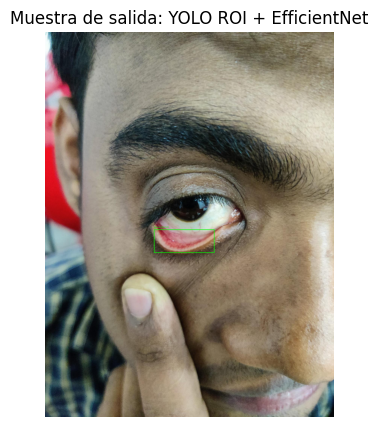

Estado: OK
Duración: 2.08 s

[PASO 11/11] Tabla comparable, README, bitácora y evidence_pack
Objetivo: Consolidar Baseline / Var1 / Var2 como entregable Semana 5 digno de tesis.
Salida esperada: comparison_results.csv + README_semana5.md + evidence_pack/
Inicio: 2026-05-08 19:10:22

TABLA COMPARABLE FINAL
experiment                  input_type status  accuracy  f1_macro  precision_macro  recall_macro  recall_anemia  recall_normal  fp_normal_as_anemia  fn_anemia_as_normal  detection_failures  detection_rate  ms_per_image  support_total
  Baseline             Imagen completa     OK  0.698246  0.697795         0.700248      0.698729       0.744681       0.652778                   50                   36                   0        1.000000     20.125029            285
      Var1     ROI con bbox real/label     OK  0.733333  0.730141         0.742643      0.732270       0.631206       0.833333                   24                   52                   0        1.000000     14.989927       

In [31]:
if __name__ == "__main__":
    warnings.filterwarnings("ignore", category=UserWarning)
    results = main(CFG)

PRUEBA VISUAL Y CUANTITATIVA DEFINITIVA - testImage
Proyecto:               C:\Users\JohnR\Desktop\Proyecto_Deteccion_Conjuntiva_v1-main
Carpeta de prueba:       C:\Users\JohnR\Desktop\Proyecto_Deteccion_Conjuntiva_v1-main\testImage
Salida principal:        C:\Users\JohnR\Desktop\Proyecto_Deteccion_Conjuntiva_v1-main\artifacts\week5_pipeline\manual_testImage_predictions
YOLO imgsz:              416
YOLO conf:               0.15
ROI margin:              0.08
Imágenes únicas por base:True
Clases del proyecto:
  0: Anemia
  1: Normal

Resumen de imágenes:
  Imágenes encontradas:       21
  Imágenes usadas en prueba:  9

Primeras imágenes a evaluar:
  Anemia\104_png.rf.09385316752ae2230e31961fd5a03f52.jpg | esperado=Anemia | fuente=txt_label
  Anemia\116_png.rf.64a25c0d2c3505bfd7408b868803848b.jpg | esperado=Anemia | fuente=txt_label
  Anemia\117_png.rf.29d5940cc82a3821e28f57eae8d1598d.jpg | esperado=Anemia | fuente=txt_label
  Anemia\121_png.rf.4d936708c8761c5c3419897739a9eaaa.jpg | esper

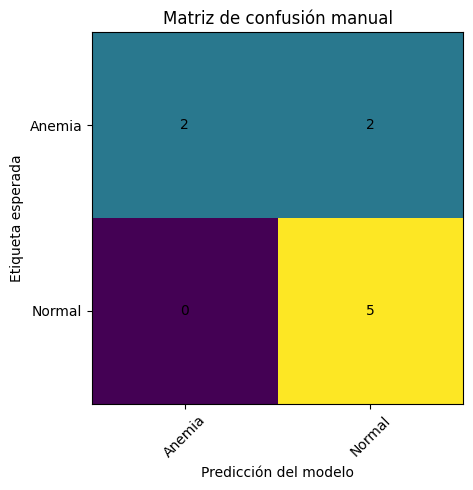

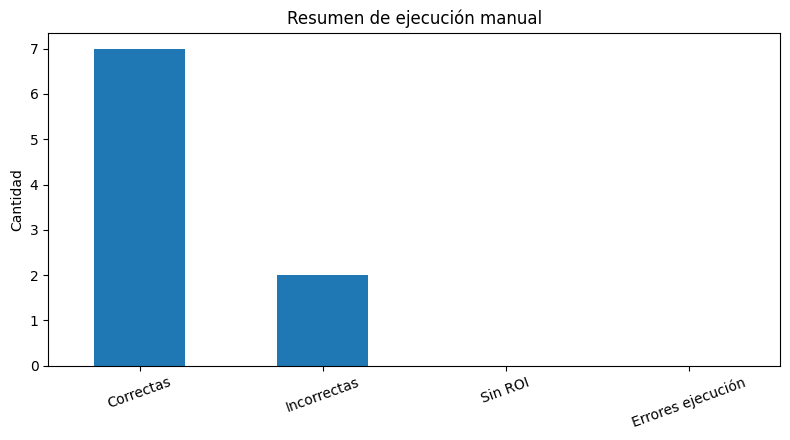

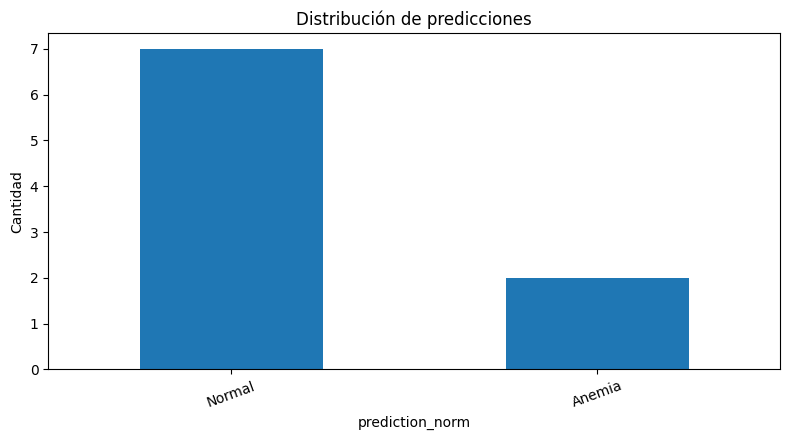


MUESTRAS VISUALES GRANDES PARA TESIS


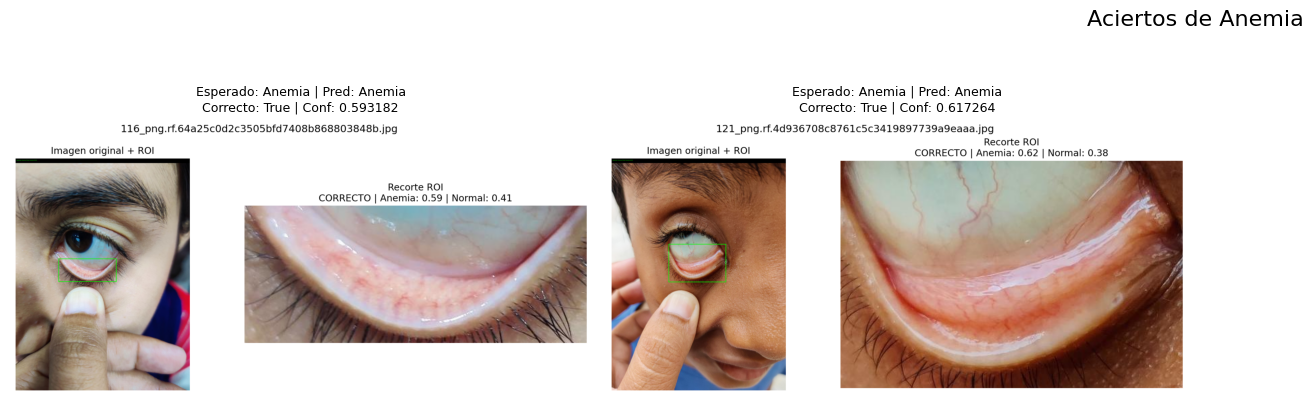

Muestra visual guardada en: C:\Users\JohnR\Desktop\Proyecto_Deteccion_Conjuntiva_v1-main\artifacts\week5_pipeline\manual_testImage_predictions\grids\muestra_aciertos_anemia.png


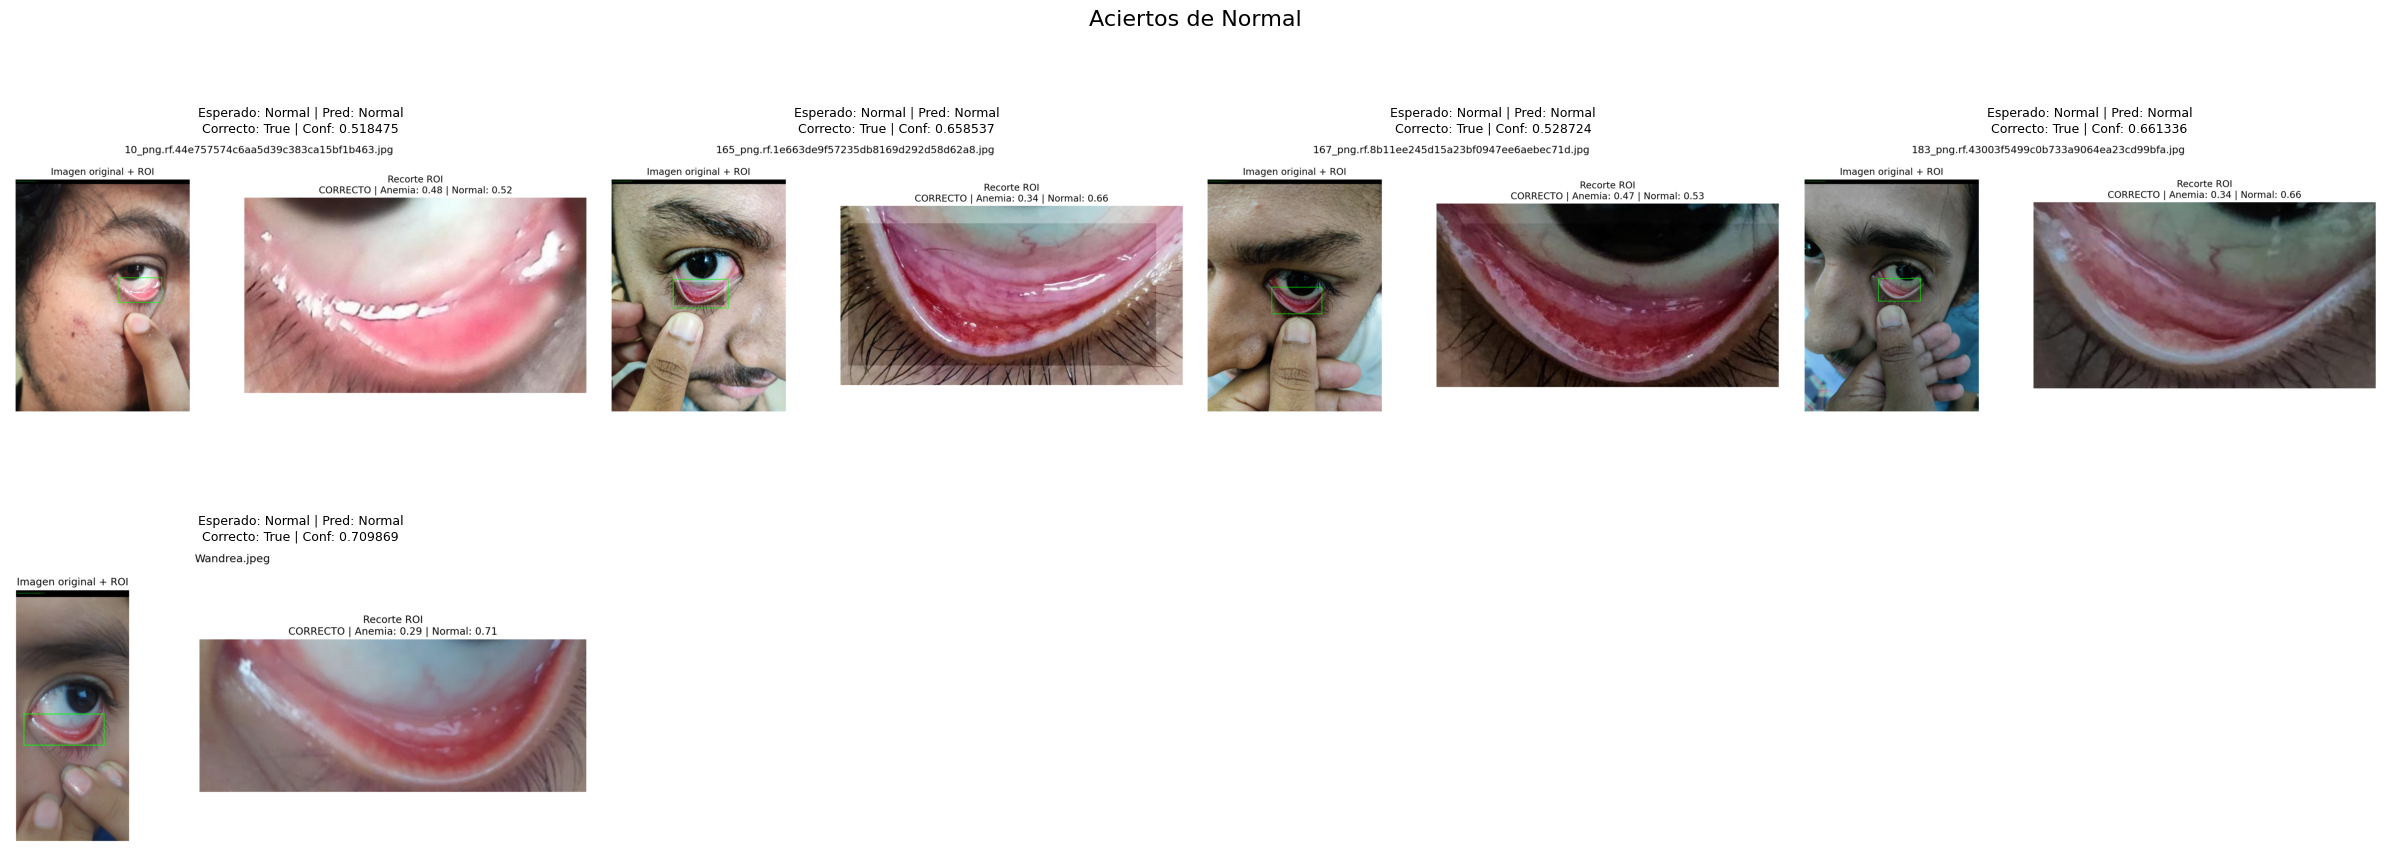

Muestra visual guardada en: C:\Users\JohnR\Desktop\Proyecto_Deteccion_Conjuntiva_v1-main\artifacts\week5_pipeline\manual_testImage_predictions\grids\muestra_aciertos_normal.png


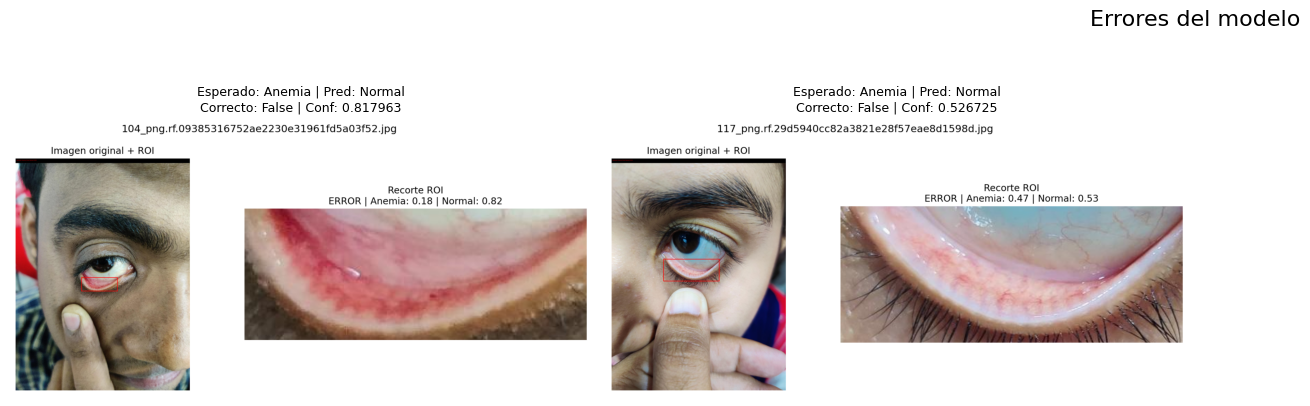

Muestra visual guardada en: C:\Users\JohnR\Desktop\Proyecto_Deteccion_Conjuntiva_v1-main\artifacts\week5_pipeline\manual_testImage_predictions\grids\muestra_errores_modelo.png


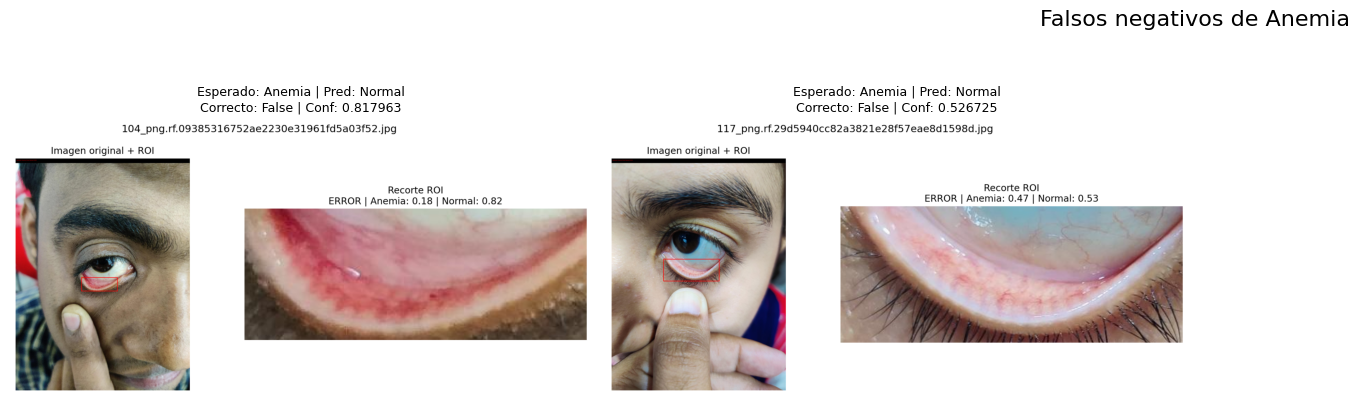

Muestra visual guardada en: C:\Users\JohnR\Desktop\Proyecto_Deteccion_Conjuntiva_v1-main\artifacts\week5_pipeline\manual_testImage_predictions\grids\muestra_falsos_negativos_anemia.png


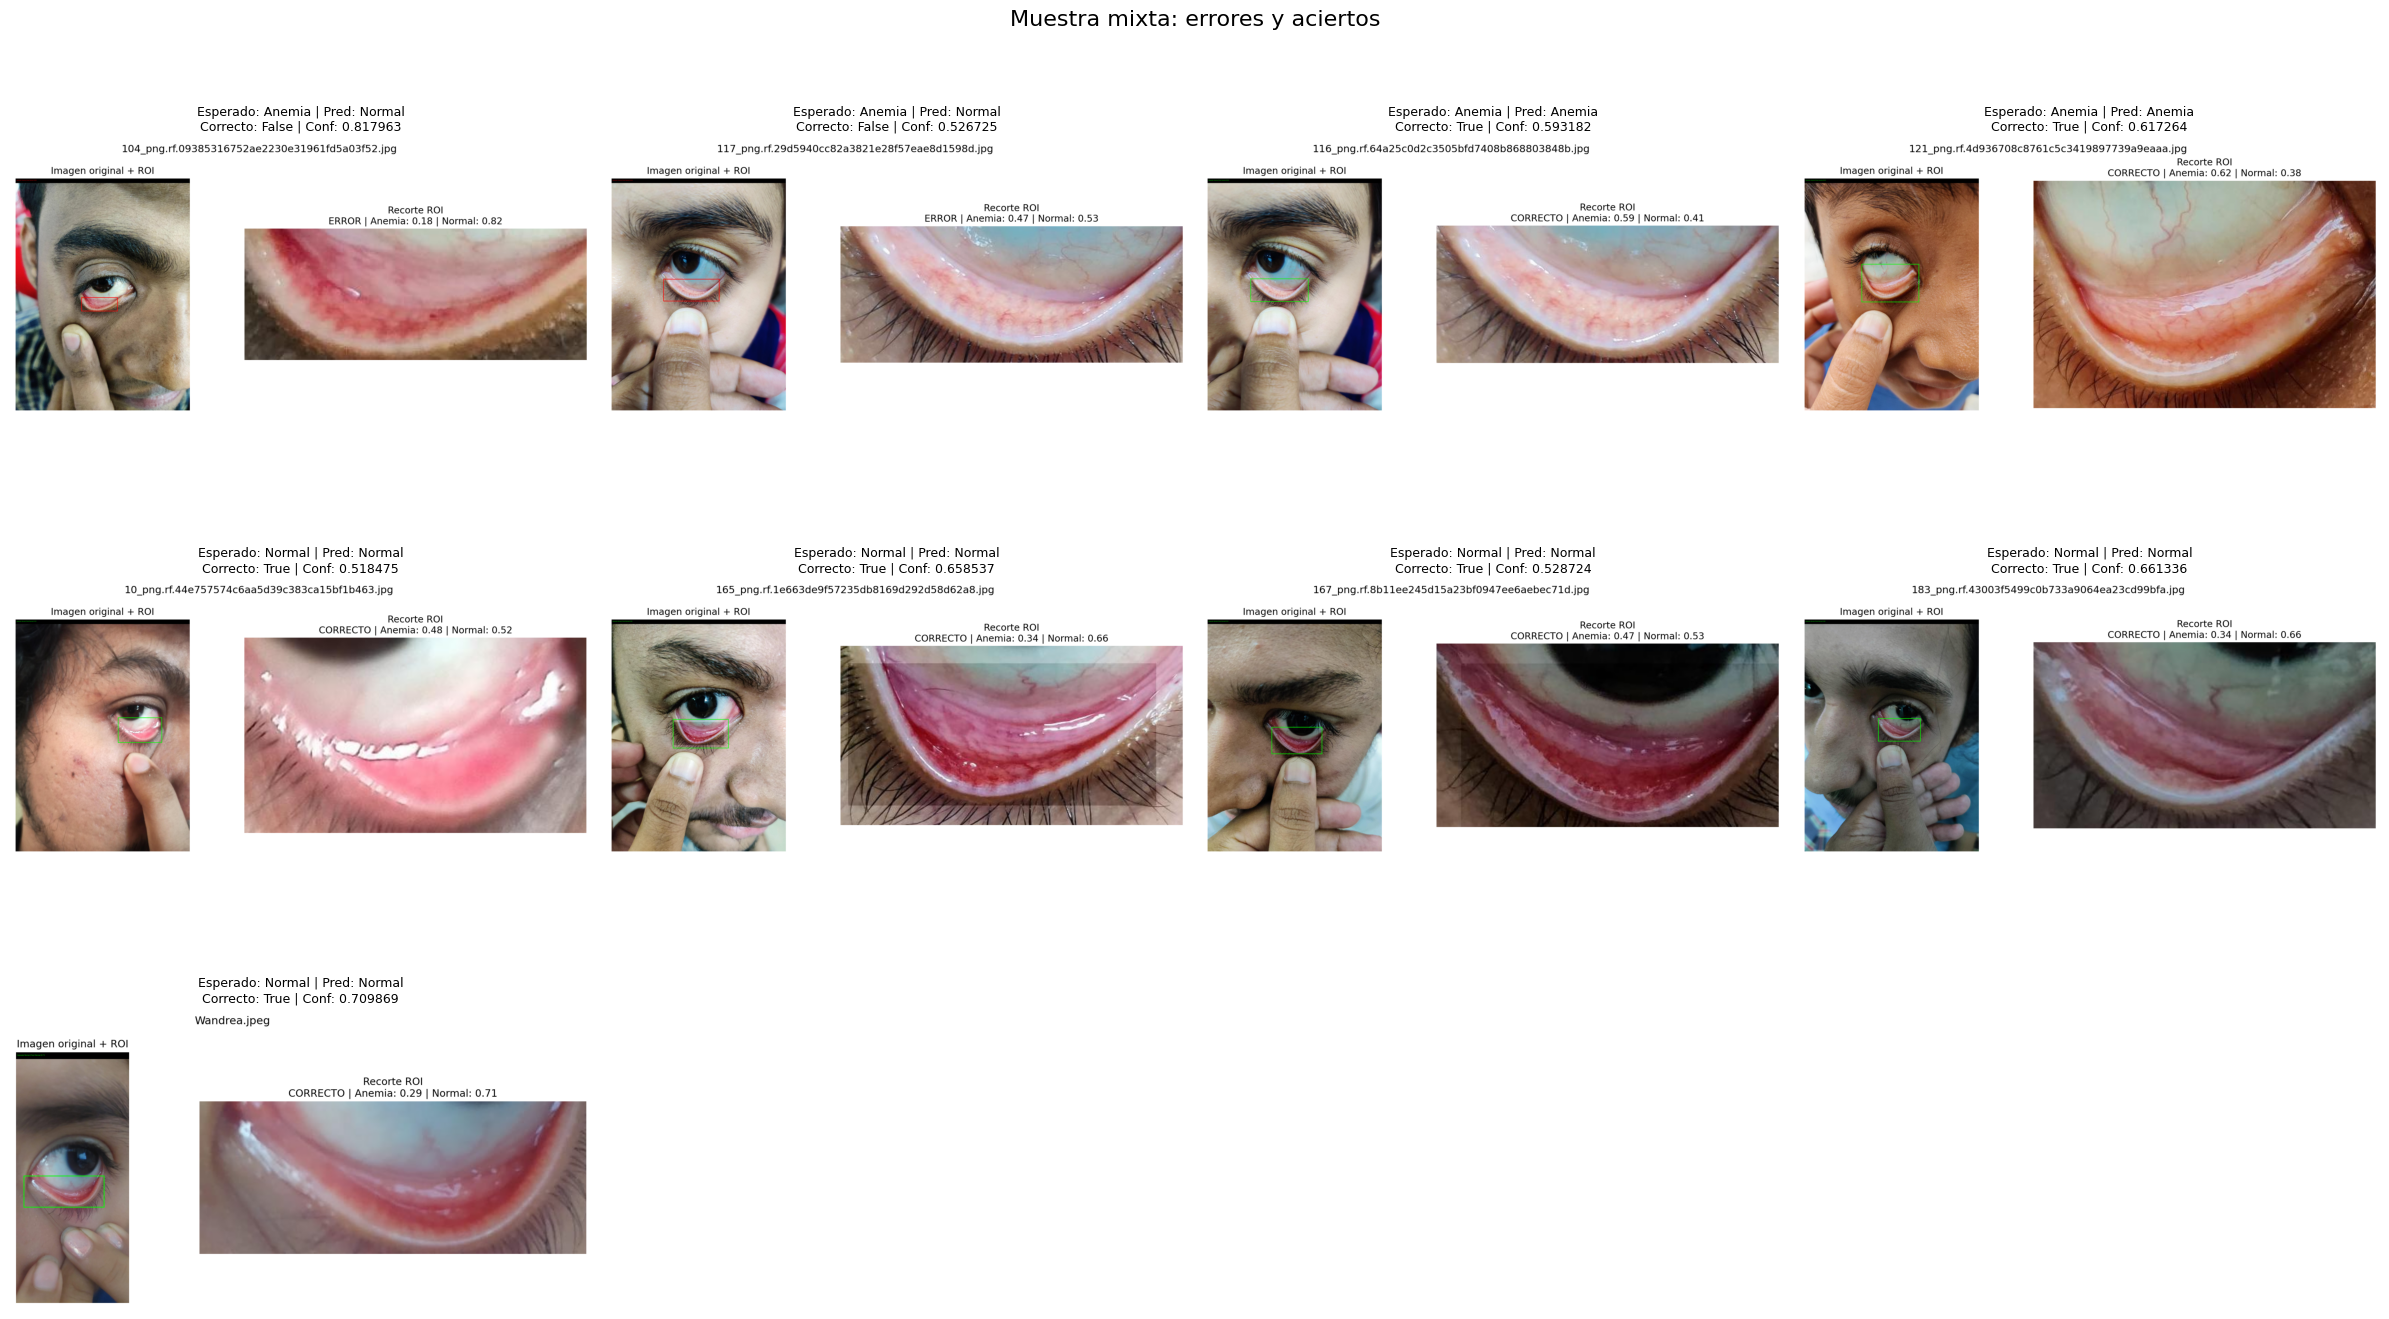

Muestra visual guardada en: C:\Users\JohnR\Desktop\Proyecto_Deteccion_Conjuntiva_v1-main\artifacts\week5_pipeline\manual_testImage_predictions\grids\muestra_visual_mixta.png

CONSOLIDADO FINAL DE PRUEBA MANUAL
Total imágenes evaluadas:       9
Procesadas OK:                  9
Con etiqueta esperada:           9
Correctas:                      7
Incorrectas:                    2
Accuracy manual:                77.78 %
Error manual:                   22.22 %
Errores de ejecución:            0
Sin ROI:                         0
Fallback a imagen completa:      0
Fallback rate:                   0.0 %
--------------------------------------------------------------------------------------------------------------
ANEMIA COMO CLASE POSITIVA
--------------------------------------------------------------------------------------------------------------
TP Anemia:                       2
FN Anemia:                       2
FP Anemia:                       0
TN Anemia:                       5
Recall

In [33]:
# /cp_v1_semana5_pipeline_TESIS_DEFENDIBLE.ipynb
# Prueba visual y cuantitativa definitiva:
# testImage -> etiqueta esperada -> YOLO ROI -> recorte -> EfficientNet -> predicción -> correcto/error
#
# Salidas generadas:
# - CSV / JSON / MD / HTML
# - matriz de confusión
# - conteo de aciertos/errores
# - paneles visuales individuales
# - grillas de aciertos Anemia, aciertos Normal, errores, falsos negativos y muestra mixta
# - reporte HTML visual para exposición/tesis

from pathlib import Path
import json
import yaml
import time
import math
import base64
from collections import Counter

import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw, ImageFont
from ultralytics import YOLO


# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

PROJECT_DIR = Path(CFG.project_dir).resolve()

TEST_IMAGE_DIR = PROJECT_DIR / "testImage"

OUTPUT_DIR = PROJECT_DIR / "artifacts" / "week5_pipeline" / "manual_testImage_predictions"
ANNOTATED_DIR = OUTPUT_DIR / "annotated"
CROPS_DIR = OUTPUT_DIR / "crops"
PANELS_DIR = OUTPUT_DIR / "panels"
GRIDS_DIR = OUTPUT_DIR / "grids"
REPORT_DIR = OUTPUT_DIR / "report"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# None = procesa todas las imágenes encontradas.
MAX_IMAGES = None

# Si True, evita repetir aumentaciones del mismo origen Roboflow.
# Para tesis se recomienda True, porque mostrar varias copias de la misma base infla la demostración visual.
USE_UNIQUE_BASE_IMAGES = True

# Si quieres ver muchas imágenes en pantalla.
MAX_VISUAL_PER_GRID = 24
MAX_HTML_CARDS = 120

# Parámetros YOLO.
YOLO_CONF = getattr(CFG, "yolo_conf_threshold", getattr(CFG, "yolo_conf", 0.15))
YOLO_IMGSZ = getattr(CFG, "yolo_imgsz", 416)
ROI_MARGIN = getattr(CFG, "roi_margin", 0.08)

# Si YOLO no detecta ROI:
# True  -> usa imagen completa como fallback.
# False -> marca NO_ROI y no clasifica.
USE_FULL_IMAGE_IF_NO_ROI = True

for folder in [OUTPUT_DIR, ANNOTATED_DIR, CROPS_DIR, PANELS_DIR, GRIDS_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("=" * 110)
print("PRUEBA VISUAL Y CUANTITATIVA DEFINITIVA - testImage")
print("=" * 110)
print(f"Proyecto:               {PROJECT_DIR}")
print(f"Carpeta de prueba:       {TEST_IMAGE_DIR}")
print(f"Salida principal:        {OUTPUT_DIR}")
print(f"YOLO imgsz:              {YOLO_IMGSZ}")
print(f"YOLO conf:               {YOLO_CONF}")
print(f"ROI margin:              {ROI_MARGIN}")
print(f"Imágenes únicas por base:{USE_UNIQUE_BASE_IMAGES}")
print("=" * 110)


# ============================================================
# 2. CARGAR CLASES DESDE data_clean.yaml
# ============================================================

DATA_YAML = Path(CFG.data_yaml)
if not DATA_YAML.is_absolute():
    DATA_YAML = PROJECT_DIR / DATA_YAML

if not DATA_YAML.exists():
    raise FileNotFoundError(f"No existe data YAML: {DATA_YAML}")

with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

names = data_cfg.get("names", {0: "Anemia", 1: "Normal"})

if isinstance(names, dict):
    class_id_to_name = {int(k): str(v) for k, v in names.items()}
else:
    class_id_to_name = {i: str(v) for i, v in enumerate(names)}

class_names = [class_id_to_name[i] for i in sorted(class_id_to_name.keys())]

name_to_class_id = {
    str(v).strip().lower(): int(k)
    for k, v in class_id_to_name.items()
}

ANEMIA_IDX = name_to_class_id.get("anemia")
NORMAL_IDX = name_to_class_id.get("normal")

print("Clases del proyecto:")
for k, v in class_id_to_name.items():
    print(f"  {k}: {v}")

if ANEMIA_IDX is None or NORMAL_IDX is None:
    print("ADVERTENCIA: no se detectaron exactamente las clases Anemia/Normal.")


# ============================================================
# 3. RECOGER IMÁGENES Y ETIQUETA ESPERADA
# ============================================================

def get_base_id(path: Path) -> str:
    """
    Roboflow suele usar nombres:
    104_png.rf.hash.jpg
    104_png.rf.otrohash.jpg

    Ambas son la misma imagen base: 104_png.
    """
    stem = path.stem
    if ".rf." in stem:
        return stem.split(".rf.")[0]
    return stem


def label_path_for_image(image_path: Path) -> Path:
    """
    Busca label .txt junto a la imagen.
    Ejemplo:
    testImage/Anemia/1.jpg -> testImage/Anemia/1.txt
    """
    return image_path.with_suffix(".txt")


def read_expected_from_yolo_txt(image_path: Path):
    """
    Lee etiqueta esperada desde archivo YOLO.
    Formato:
    0 x_center y_center width height
    1 x_center y_center width height

    Si hay varias cajas, usa clase mayoritaria.
    """
    label_path = label_path_for_image(image_path)

    if not label_path.exists():
        return None, None, "no_txt"

    classes = []

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue

            try:
                cls_id = int(float(parts[0]))
                classes.append(cls_id)
            except ValueError:
                continue

    if not classes:
        return None, None, "txt_empty"

    cls_id = Counter(classes).most_common(1)[0][0]
    cls_name = class_id_to_name.get(cls_id, str(cls_id))

    return cls_id, cls_name, "txt_label"


def read_expected_from_folder(image_path: Path):
    """
    Si no existe .txt, usa nombre de carpeta:
    testImage/Anemia/1.jpg -> Anemia
    testImage/Normal/2.jpg -> Normal
    """
    parent_name = image_path.parent.name.strip().lower()

    if parent_name in name_to_class_id:
        cls_id = name_to_class_id[parent_name]
        cls_name = class_id_to_name[cls_id]
        return cls_id, cls_name, "folder_label"

    return None, None, "unknown"


def get_expected_label(image_path: Path):
    """
    Orden:
    1. Label YOLO .txt.
    2. Nombre de carpeta Anemia/Normal.
    3. Unknown.
    """
    cls_id, cls_name, source = read_expected_from_yolo_txt(image_path)

    if cls_id is not None:
        return cls_id, cls_name, source

    return read_expected_from_folder(image_path)


if not TEST_IMAGE_DIR.exists():
    raise FileNotFoundError(
        f"No existe la carpeta testImage:\n{TEST_IMAGE_DIR}\n\n"
        "Crea la carpeta y coloca imágenes dentro."
    )

all_images = sorted([
    p for p in TEST_IMAGE_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
])

if not all_images:
    raise FileNotFoundError(f"No hay imágenes válidas en: {TEST_IMAGE_DIR}")

if USE_UNIQUE_BASE_IMAGES:
    unique_by_base = {}
    for image_path in all_images:
        base_id = get_base_id(image_path)
        if base_id not in unique_by_base:
            unique_by_base[base_id] = image_path
    image_paths = list(unique_by_base.values())
else:
    image_paths = all_images

if MAX_IMAGES is not None:
    image_paths = image_paths[:MAX_IMAGES]

print("\nResumen de imágenes:")
print(f"  Imágenes encontradas:       {len(all_images)}")
print(f"  Imágenes usadas en prueba:  {len(image_paths)}")

print("\nPrimeras imágenes a evaluar:")
for p in image_paths[:15]:
    expected_id, expected_name, expected_source = get_expected_label(p)
    print(f"  {p.relative_to(TEST_IMAGE_DIR)} | esperado={expected_name} | fuente={expected_source}")


# ============================================================
# 4. BUSCAR PESOS DE YOLO Y CLASIFICADOR ROI
# ============================================================

ARTIFACT_DIR = PROJECT_DIR / "artifacts" / "week5_pipeline"

YOLO_WEIGHTS_CANDIDATES = [
    PROJECT_DIR / "runs" / "detect" / "week5_yolo_quick" / "weights" / "best.pt",
    PROJECT_DIR / "runs" / "detect" / "week5_yolo_real" / "weights" / "best.pt",
]

CLASSIFIER_WEIGHTS_CANDIDATES = [
    ARTIFACT_DIR / "roi_gt" / "best.pt",
    ARTIFACT_DIR / "roi_gt" / "best_model.pt",
    ARTIFACT_DIR / "roi_gt" / "best_classifier.pt",
]


def find_first_existing(paths, label, fallback_glob=None):
    for p in paths:
        if p.exists():
            print(f"{label}: {p}")
            return p

    if fallback_glob is not None:
        found = sorted(fallback_glob())
        if found:
            print(f"{label}: {found[0]}")
            return found[0]

    raise FileNotFoundError(
        f"No se encontró peso para {label}.\n"
        "Primero ejecuta el pipeline de entrenamiento para generar pesos."
    )


YOLO_WEIGHTS = find_first_existing(
    YOLO_WEIGHTS_CANDIDATES,
    "YOLO",
    fallback_glob=lambda: list((PROJECT_DIR / "runs" / "detect").glob("**/best.pt")),
)

CLASSIFIER_WEIGHTS = find_first_existing(
    CLASSIFIER_WEIGHTS_CANDIDATES,
    "Clasificador ROI",
    fallback_glob=lambda: list((ARTIFACT_DIR / "roi_gt").glob("*.pt")),
)


# ============================================================
# 5. CARGAR MODELOS Y TRANSFORMACIONES
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n" + "=" * 110)
print("DISPOSITIVO Y MODELOS")
print("=" * 110)
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print("=" * 110)

detector = YOLO(str(YOLO_WEIGHTS))

classifier = load_classifier_checkpoint(
    checkpoint_path=CLASSIFIER_WEIGHTS,
    cfg=CFG,
    device=device,
)
classifier.eval()

_, eval_tf = build_transforms(CFG)


# ============================================================
# 6. CARGAR UMBRAL VALIDADO SI EXISTE
# ============================================================

threshold_anemia = None

threshold_candidates = [
    ARTIFACT_DIR / "yolo_e2e" / "threshold.json",
    ARTIFACT_DIR / "yolo_e2e" / "calibration.json",
    ARTIFACT_DIR / "yolo_e2e" / "e2e_calibration.json",
    ARTIFACT_DIR / "yolo_e2e" / "e2e_calibration.pt",
]

for tp in threshold_candidates:
    if not tp.exists():
        continue

    try:
        if tp.suffix.lower() == ".json":
            data = json.loads(tp.read_text(encoding="utf-8"))
            for key in ["threshold_anemia", "best_threshold", "threshold"]:
                if key in data:
                    threshold_anemia = float(data[key])
                    print(f"Umbral Anemia cargado desde {tp.name}: {threshold_anemia}")
                    break

        elif tp.suffix.lower() == ".pt":
            data = torch.load(tp, map_location="cpu")
            if isinstance(data, dict) and "threshold_anemia" in data:
                threshold_anemia = float(data["threshold_anemia"])
                print(f"Umbral Anemia cargado desde {tp.name}: {threshold_anemia}")

        if threshold_anemia is not None:
            break

    except Exception:
        pass

if threshold_anemia is None:
    print("No se encontró umbral validado. Se usará argmax.")


# ============================================================
# 7. FUNCIONES DE INFERENCIA Y VISUALIZACIÓN
# ============================================================

def normalize_label(value):
    if value is None:
        return None
    if pd.isna(value):
        return None
    return str(value).strip()


def safe_div(numerator, denominator):
    return float(numerator / denominator) if denominator else 0.0


def pct(value):
    return round(float(value) * 100, 2)


def safe_file_stem(path: Path) -> str:
    return (
        path.stem
        .replace(" ", "_")
        .replace("/", "_")
        .replace("\\", "_")
        .replace(":", "_")
    )


def choose_prediction(probs):
    """
    Si existe umbral validado para Anemia, usa ese umbral.
    Si no existe, usa argmax.
    """
    if threshold_anemia is not None and ANEMIA_IDX is not None:
        if probs[ANEMIA_IDX] >= threshold_anemia:
            pred_idx = ANEMIA_IDX
        else:
            other_indices = [i for i in range(len(probs)) if i != ANEMIA_IDX]
            pred_idx = max(other_indices, key=lambda i: probs[i])
    else:
        pred_idx = int(probs.argmax())

    pred_name = class_id_to_name.get(pred_idx, str(pred_idx))
    pred_conf = float(probs[pred_idx])

    return pred_idx, pred_name, pred_conf


def detect_roi(image_path: Path, image: Image.Image):
    """
    Ejecuta YOLO y devuelve ROI + metadatos.
    """
    w, h = image.size

    pred = detector.predict(
        source=str(image_path),
        imgsz=YOLO_IMGSZ,
        conf=YOLO_CONF,
        device=0 if device.type == "cuda" else "cpu",
        verbose=False,
    )[0]

    boxes = pred.boxes

    if boxes is None or len(boxes) == 0:
        if not USE_FULL_IMAGE_IF_NO_ROI:
            return None

        return {
            "x1": 0,
            "y1": 0,
            "x2": w,
            "y2": h,
            "yolo_conf": None,
            "yolo_cls": None,
            "yolo_cls_name": None,
            "num_boxes": 0,
            "used_fallback": True,
        }

    confs = boxes.conf.detach().cpu()
    best_idx = int(torch.argmax(confs).item())

    x1, y1, x2, y2 = boxes.xyxy[best_idx].detach().cpu().numpy().tolist()

    yolo_conf = float(boxes.conf[best_idx].detach().cpu().item())
    yolo_cls = int(boxes.cls[best_idx].detach().cpu().item())

    bw = x2 - x1
    bh = y2 - y1

    x1 = max(0, int(x1 - bw * ROI_MARGIN))
    y1 = max(0, int(y1 - bh * ROI_MARGIN))
    x2 = min(w, int(x2 + bw * ROI_MARGIN))
    y2 = min(h, int(y2 + bh * ROI_MARGIN))

    if x2 <= x1 or y2 <= y1:
        if not USE_FULL_IMAGE_IF_NO_ROI:
            return None

        return {
            "x1": 0,
            "y1": 0,
            "x2": w,
            "y2": h,
            "yolo_conf": yolo_conf,
            "yolo_cls": yolo_cls,
            "yolo_cls_name": class_id_to_name.get(yolo_cls, str(yolo_cls)),
            "num_boxes": int(len(boxes)),
            "used_fallback": True,
        }

    return {
        "x1": x1,
        "y1": y1,
        "x2": x2,
        "y2": y2,
        "yolo_conf": yolo_conf,
        "yolo_cls": yolo_cls,
        "yolo_cls_name": class_id_to_name.get(yolo_cls, str(yolo_cls)),
        "num_boxes": int(len(boxes)),
        "used_fallback": False,
    }


def classify_crop(crop: Image.Image):
    tensor = eval_tf(crop).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = classifier(tensor)
        probs = F.softmax(logits, dim=1).detach().cpu().numpy()[0]

    pred_idx, pred_name, pred_conf = choose_prediction(probs)

    return pred_idx, pred_name, pred_conf, probs


def make_annotated_image(image, roi, expected_name, pred_name, pred_conf, is_correct):
    annotated = image.copy()
    draw = ImageDraw.Draw(annotated)

    x1, y1, x2, y2 = roi["x1"], roi["y1"], roi["x2"], roi["y2"]

    color = "lime" if is_correct else "red"

    draw.rectangle((x1, y1, x2, y2), outline=color, width=5)

    header = f"Esperado: {expected_name} | Pred: {pred_name} ({pred_conf:.2f})"
    if roi["used_fallback"]:
        header += " | fallback"

    draw.rectangle((0, 0, annotated.width, 42), fill="black")
    draw.text((8, 12), header, fill=color)

    return annotated


def make_panel(image, crop, roi, expected_name, pred_name, pred_conf, probs, is_correct, image_name):
    annotated = make_annotated_image(
        image=image,
        roi=roi,
        expected_name=expected_name,
        pred_name=pred_name,
        pred_conf=pred_conf,
        is_correct=is_correct,
    )

    prob_text = " | ".join([
        f"{class_id_to_name.get(i, str(i))}: {float(p):.2f}"
        for i, p in enumerate(probs)
    ])

    verdict = "CORRECTO" if is_correct else "ERROR"

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(annotated)
    axes[0].axis("off")
    axes[0].set_title("Imagen original + ROI")

    axes[1].imshow(crop)
    axes[1].axis("off")
    axes[1].set_title(f"Recorte ROI\n{verdict} | {prob_text}")

    fig.suptitle(image_name, fontsize=13)
    plt.tight_layout()

    return fig, annotated


def dataframe_to_markdown_safe(dataframe: pd.DataFrame) -> str:
    if dataframe is None or dataframe.empty:
        return "_Sin resultados disponibles._"

    safe_df = dataframe.copy().fillna("")
    headers = [str(c) for c in safe_df.columns]
    rows = safe_df.astype(str).values.tolist()

    def clean(value: str) -> str:
        return str(value).replace("\n", "<br>").replace("|", "\\|")

    lines = []
    lines.append("| " + " | ".join(clean(h) for h in headers) + " |")
    lines.append("| " + " | ".join("---" for _ in headers) + " |")

    for row in rows:
        lines.append("| " + " | ".join(clean(cell) for cell in row) + " |")

    return "\n".join(lines)


def encode_image_base64(image_path: Path) -> str:
    if not image_path.exists():
        return ""

    suffix = image_path.suffix.lower().replace(".", "")
    mime = "jpeg" if suffix in {"jpg", "jpeg"} else "png"

    data = image_path.read_bytes()
    encoded = base64.b64encode(data).decode("utf-8")
    return f"data:image/{mime};base64,{encoded}"


# ============================================================
# 8. EJECUTAR INFERENCIA
# ============================================================

records = []
start_all = time.time()

print("\n" + "=" * 110)
print("EJECUTANDO INFERENCIA CON COMPARACIÓN CONTRA ETIQUETA ESPERADA")
print("=" * 110)

for idx, image_path in enumerate(image_paths, start=1):
    start = time.time()

    try:
        expected_id, expected_name, expected_source = get_expected_label(image_path)

        image = Image.open(image_path).convert("RGB")

        roi = detect_roi(image_path, image)

        if roi is None:
            record = {
                "image": str(image_path),
                "relative_image": str(image_path.relative_to(TEST_IMAGE_DIR)),
                "base_id": get_base_id(image_path),
                "status": "NO_ROI",
                "expected_index": expected_id,
                "expected": expected_name,
                "expected_source": expected_source,
                "prediction_index": None,
                "prediction": None,
                "confidence": None,
                "correct": None,
                "elapsed_seconds": round(time.time() - start, 4),
            }
            records.append(record)
            print(f"[{idx}/{len(image_paths)}] NO_ROI -> {image_path.name}")
            continue

        crop = image.crop((roi["x1"], roi["y1"], roi["x2"], roi["y2"]))

        pred_idx, pred_name, pred_conf, probs = classify_crop(crop)

        if expected_name is not None:
            is_correct = str(pred_name).strip().lower() == str(expected_name).strip().lower()
        else:
            is_correct = None

        base = safe_file_stem(image_path)

        annotated_path = ANNOTATED_DIR / f"{base}_annotated.png"
        crop_path = CROPS_DIR / f"{base}_crop.png"
        panel_path = PANELS_DIR / f"{base}_panel.png"

        panel_fig, annotated = make_panel(
            image=image,
            crop=crop,
            roi=roi,
            expected_name=expected_name,
            pred_name=pred_name,
            pred_conf=pred_conf,
            probs=probs,
            is_correct=bool(is_correct),
            image_name=image_path.name,
        )

        annotated.save(annotated_path)
        crop.save(crop_path)
        panel_fig.savefig(panel_path, dpi=170, bbox_inches="tight")
        plt.close(panel_fig)

        record = {
            "image": str(image_path),
            "relative_image": str(image_path.relative_to(TEST_IMAGE_DIR)),
            "base_id": get_base_id(image_path),
            "status": "OK",
            "expected_index": expected_id,
            "expected": expected_name,
            "expected_source": expected_source,
            "prediction_index": pred_idx,
            "prediction": pred_name,
            "confidence": round(pred_conf, 6),
            "correct": is_correct,
            "used_threshold_anemia": threshold_anemia,
            "yolo_conf": None if roi["yolo_conf"] is None else round(float(roi["yolo_conf"]), 6),
            "yolo_cls": roi["yolo_cls"],
            "yolo_cls_name": roi["yolo_cls_name"],
            "used_fallback": roi["used_fallback"],
            "num_boxes": roi["num_boxes"],
            "x1": roi["x1"],
            "y1": roi["y1"],
            "x2": roi["x2"],
            "y2": roi["y2"],
            "crop_path": str(crop_path),
            "annotated_path": str(annotated_path),
            "panel_path": str(panel_path),
            "elapsed_seconds": round(time.time() - start, 4),
        }

        for cls_i, p in enumerate(probs):
            label = class_id_to_name.get(cls_i, f"class_{cls_i}")
            record[f"prob_{label}"] = round(float(p), 6)

        records.append(record)

        verdict = "OK" if is_correct else "ERROR"

        print(
            f"[{idx}/{len(image_paths)}] {image_path.name} | "
            f"Esperado={expected_name} | Pred={pred_name} ({pred_conf:.3f}) | "
            f"{verdict} | YOLO={record['yolo_conf']} | fallback={roi['used_fallback']}"
        )

    except Exception as exc:
        record = {
            "image": str(image_path),
            "relative_image": str(image_path.relative_to(TEST_IMAGE_DIR)),
            "base_id": get_base_id(image_path),
            "status": "ERROR",
            "expected": None,
            "prediction": None,
            "correct": None,
            "error": repr(exc),
            "elapsed_seconds": round(time.time() - start, 4),
        }
        records.append(record)
        print(f"[{idx}/{len(image_paths)}] ERROR -> {image_path.name}: {repr(exc)}")

elapsed_all = time.time() - start_all

print("=" * 110)
print(f"Inferencia finalizada en {elapsed_all:.2f} segundos")
print("=" * 110)


# ============================================================
# 9. CONSOLIDADO CUANTITATIVO
# ============================================================

df = pd.DataFrame(records)

predictions_csv_path = OUTPUT_DIR / "predicciones_con_ground_truth.csv"
predictions_json_path = OUTPUT_DIR / "predicciones_con_ground_truth.json"
predictions_md_path = OUTPUT_DIR / "predicciones_con_ground_truth.md"

consolidated_json_path = OUTPUT_DIR / "consolidado_tesis.json"
consolidated_csv_path = OUTPUT_DIR / "consolidado_tesis.csv"
consolidated_md_path = OUTPUT_DIR / "consolidado_tesis.md"
html_report_path = REPORT_DIR / "reporte_visual_tesis.html"

errors_csv_path = OUTPUT_DIR / "errores_modelo.csv"
correct_csv_path = OUTPUT_DIR / "aciertos_modelo.csv"
false_negative_path = OUTPUT_DIR / "falsos_negativos_anemia.csv"
false_positive_path = OUTPUT_DIR / "falsos_positivos_anemia.csv"

confusion_png_path = GRIDS_DIR / "matriz_confusion_manual.png"
counts_png_path = GRIDS_DIR / "conteo_correctos_errores.png"
prediction_dist_png_path = GRIDS_DIR / "distribucion_predicciones.png"

df.to_csv(predictions_csv_path, index=False, encoding="utf-8")
predictions_json_path.write_text(
    json.dumps(records, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

if "status" not in df.columns:
    df["status"] = "UNKNOWN"

if "expected" not in df.columns:
    df["expected"] = None

if "prediction" not in df.columns:
    df["prediction"] = None

if "correct" not in df.columns:
    df["correct"] = None

df["expected_norm"] = df["expected"].apply(normalize_label)
df["prediction_norm"] = df["prediction"].apply(normalize_label)

ok_df = df[df["status"] == "OK"].copy()
gt_df = ok_df[
    ok_df["expected_norm"].notna() &
    ok_df["prediction_norm"].notna()
].copy()

if not gt_df.empty:
    gt_df["correct"] = gt_df["expected_norm"].str.lower() == gt_df["prediction_norm"].str.lower()

    for row_idx, row in gt_df.iterrows():
        df.loc[row_idx, "correct"] = bool(row["correct"])

total_images = int(len(df))
ok_count = int((df["status"] == "OK").sum())
error_exec_count = int((df["status"] == "ERROR").sum())
no_roi_count = int((df["status"] == "NO_ROI").sum())
with_gt_count = int(len(gt_df))

correct_count = int((gt_df["correct"] == True).sum()) if not gt_df.empty else 0
incorrect_count = int((gt_df["correct"] == False).sum()) if not gt_df.empty else 0

accuracy_manual = safe_div(correct_count, with_gt_count)
error_rate_manual = safe_div(incorrect_count, with_gt_count)

fallback_count = int(df["used_fallback"].fillna(False).sum()) if "used_fallback" in df.columns else 0
fallback_rate = safe_div(fallback_count, ok_count)

avg_inference_time = (
    float(df["elapsed_seconds"].dropna().mean())
    if "elapsed_seconds" in df.columns and not df["elapsed_seconds"].dropna().empty
    else None
)

total_inference_time = (
    float(df["elapsed_seconds"].dropna().sum())
    if "elapsed_seconds" in df.columns and not df["elapsed_seconds"].dropna().empty
    else None
)

summary_status = df["status"].value_counts(dropna=False).to_dict()
summary_expected = df["expected_norm"].value_counts(dropna=False).to_dict()
summary_prediction = df["prediction_norm"].value_counts(dropna=False).to_dict()

class_labels = [str(v) for _, v in sorted(class_id_to_name.items(), key=lambda item: item[0])]

if not gt_df.empty:
    confusion_df = pd.crosstab(
        gt_df["expected_norm"],
        gt_df["prediction_norm"],
        rownames=["Etiqueta esperada"],
        colnames=["Predicción modelo"],
        dropna=False,
    )

    for label in class_labels:
        if label not in confusion_df.index:
            confusion_df.loc[label] = 0
        if label not in confusion_df.columns:
            confusion_df[label] = 0

    confusion_df = confusion_df.loc[class_labels, class_labels]
else:
    confusion_df = pd.DataFrame(0, index=class_labels, columns=class_labels)
    confusion_df.index.name = "Etiqueta esperada"
    confusion_df.columns.name = "Predicción modelo"

per_class_rows = []

for label in class_labels:
    if not gt_df.empty:
        expected_is_label = gt_df["expected_norm"].str.lower() == label.lower()
        predicted_is_label = gt_df["prediction_norm"].str.lower() == label.lower()
    else:
        expected_is_label = pd.Series(dtype=bool)
        predicted_is_label = pd.Series(dtype=bool)

    tp = int((expected_is_label & predicted_is_label).sum()) if not gt_df.empty else 0
    fp = int((~expected_is_label & predicted_is_label).sum()) if not gt_df.empty else 0
    fn = int((expected_is_label & ~predicted_is_label).sum()) if not gt_df.empty else 0
    tn = int((~expected_is_label & ~predicted_is_label).sum()) if not gt_df.empty else 0

    precision = safe_div(tp, tp + fp)
    recall = safe_div(tp, tp + fn)
    f1 = safe_div(2 * precision * recall, precision + recall)

    per_class_rows.append({
        "clase": label,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "precision_%": pct(precision),
        "recall_%": pct(recall),
        "f1_%": pct(f1),
    })

per_class_df = pd.DataFrame(per_class_rows)

macro_precision = float(per_class_df["precision"].mean()) if not per_class_df.empty else 0.0
macro_recall = float(per_class_df["recall"].mean()) if not per_class_df.empty else 0.0
macro_f1 = float(per_class_df["f1"].mean()) if not per_class_df.empty else 0.0

anemia_label = next((label for label in class_labels if label.lower() == "anemia"), None)

tp_anemia = fp_anemia = fn_anemia = tn_anemia = 0
false_negative_anemia_df = pd.DataFrame()
false_positive_anemia_df = pd.DataFrame()

if anemia_label is not None and not gt_df.empty:
    expected_anemia = gt_df["expected_norm"].str.lower() == anemia_label.lower()
    predicted_anemia = gt_df["prediction_norm"].str.lower() == anemia_label.lower()

    tp_anemia = int((expected_anemia & predicted_anemia).sum())
    fn_anemia = int((expected_anemia & ~predicted_anemia).sum())
    fp_anemia = int((~expected_anemia & predicted_anemia).sum())
    tn_anemia = int((~expected_anemia & ~predicted_anemia).sum())

    false_negative_anemia_df = gt_df[expected_anemia & ~predicted_anemia].copy()
    false_positive_anemia_df = gt_df[~expected_anemia & predicted_anemia].copy()

recall_anemia = safe_div(tp_anemia, tp_anemia + fn_anemia)
precision_anemia = safe_div(tp_anemia, tp_anemia + fp_anemia)
f1_anemia = safe_div(2 * precision_anemia * recall_anemia, precision_anemia + recall_anemia)

correct_df = gt_df[gt_df["correct"] == True].copy() if not gt_df.empty else pd.DataFrame()
incorrect_df = gt_df[gt_df["correct"] == False].copy() if not gt_df.empty else pd.DataFrame()

correct_df.to_csv(correct_csv_path, index=False, encoding="utf-8")
incorrect_df.to_csv(errors_csv_path, index=False, encoding="utf-8")
false_negative_anemia_df.to_csv(false_negative_path, index=False, encoding="utf-8")
false_positive_anemia_df.to_csv(false_positive_path, index=False, encoding="utf-8")

summary_df = pd.DataFrame([
    {"indicador": "Total de imágenes evaluadas", "valor": total_images},
    {"indicador": "Procesadas OK", "valor": ok_count},
    {"indicador": "Con etiqueta esperada", "valor": with_gt_count},
    {"indicador": "Correctas", "valor": correct_count},
    {"indicador": "Incorrectas", "valor": incorrect_count},
    {"indicador": "Accuracy manual (%)", "valor": pct(accuracy_manual)},
    {"indicador": "Error manual (%)", "valor": pct(error_rate_manual)},
    {"indicador": "Errores de ejecución", "valor": error_exec_count},
    {"indicador": "Sin ROI", "valor": no_roi_count},
    {"indicador": "Fallback a imagen completa", "valor": fallback_count},
    {"indicador": "Fallback rate (%)", "valor": pct(fallback_rate)},
    {"indicador": "TP Anemia", "valor": tp_anemia},
    {"indicador": "FN Anemia", "valor": fn_anemia},
    {"indicador": "FP Anemia", "valor": fp_anemia},
    {"indicador": "TN Anemia", "valor": tn_anemia},
    {"indicador": "Recall Anemia (%)", "valor": pct(recall_anemia)},
    {"indicador": "Precision Anemia (%)", "valor": pct(precision_anemia)},
    {"indicador": "F1 Anemia (%)", "valor": pct(f1_anemia)},
    {"indicador": "Macro F1 (%)", "valor": pct(macro_f1)},
])

summary_df.to_csv(consolidated_csv_path, index=False, encoding="utf-8")

summary_payload = {
    "total_images": total_images,
    "status_counts": summary_status,
    "ok_count": ok_count,
    "execution_error_count": error_exec_count,
    "no_roi_count": no_roi_count,
    "with_ground_truth_count": with_gt_count,
    "correct_count": correct_count,
    "incorrect_count": incorrect_count,
    "accuracy_manual": round(accuracy_manual, 6),
    "accuracy_manual_percent": pct(accuracy_manual),
    "error_rate_manual": round(error_rate_manual, 6),
    "error_rate_manual_percent": pct(error_rate_manual),
    "fallback_count": fallback_count,
    "fallback_rate": round(fallback_rate, 6),
    "fallback_rate_percent": pct(fallback_rate),
    "avg_inference_time_seconds": None if avg_inference_time is None else round(avg_inference_time, 6),
    "total_inference_time_seconds": None if total_inference_time is None else round(total_inference_time, 6),
    "expected_counts": summary_expected,
    "prediction_counts": summary_prediction,
    "class_metrics": per_class_rows,
    "macro_precision": round(macro_precision, 6),
    "macro_recall": round(macro_recall, 6),
    "macro_f1": round(macro_f1, 6),
    "anemia_as_positive": {
        "label": anemia_label,
        "TP": tp_anemia,
        "FP": fp_anemia,
        "FN": fn_anemia,
        "TN": tn_anemia,
        "precision": round(precision_anemia, 6),
        "recall": round(recall_anemia, 6),
        "f1": round(f1_anemia, 6),
        "precision_percent": pct(precision_anemia),
        "recall_percent": pct(recall_anemia),
        "f1_percent": pct(f1_anemia),
    },
}

consolidated_json_path.write_text(
    json.dumps(summary_payload, indent=2, ensure_ascii=False),
    encoding="utf-8",
)


# ============================================================
# 10. GRÁFICOS CUANTITATIVOS
# ============================================================

plt.figure(figsize=(7, 5))
conf_values = confusion_df.values.astype(int)
plt.imshow(conf_values)
plt.title("Matriz de confusión manual")
plt.xlabel("Predicción del modelo")
plt.ylabel("Etiqueta esperada")
plt.xticks(range(len(confusion_df.columns)), confusion_df.columns, rotation=45)
plt.yticks(range(len(confusion_df.index)), confusion_df.index)

for row_idx in range(conf_values.shape[0]):
    for col_idx in range(conf_values.shape[1]):
        plt.text(
            col_idx,
            row_idx,
            str(conf_values[row_idx, col_idx]),
            ha="center",
            va="center",
        )

plt.tight_layout()
plt.savefig(confusion_png_path, dpi=170, bbox_inches="tight")
plt.show()

counts_series = pd.Series({
    "Correctas": correct_count,
    "Incorrectas": incorrect_count,
    "Sin ROI": no_roi_count,
    "Errores ejecución": error_exec_count,
})

plt.figure(figsize=(8, 4.5))
counts_series.plot(kind="bar")
plt.title("Resumen de ejecución manual")
plt.ylabel("Cantidad")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(counts_png_path, dpi=170, bbox_inches="tight")
plt.show()

if "prediction_norm" in df.columns:
    pred_counts_series = df["prediction_norm"].value_counts(dropna=False)

    plt.figure(figsize=(8, 4.5))
    pred_counts_series.plot(kind="bar")
    plt.title("Distribución de predicciones")
    plt.ylabel("Cantidad")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(prediction_dist_png_path, dpi=170, bbox_inches="tight")
    plt.show()


# ============================================================
# 11. GRILLAS VISUALES GRANDES
# ============================================================

def show_panel_grid(rows_df: pd.DataFrame, title: str, output_name: str, max_items: int = 24):
    if rows_df is None or rows_df.empty or "panel_path" not in rows_df.columns:
        print(f"No hay paneles para mostrar: {title}")
        return None

    rows_to_show = rows_df.head(max_items)

    cols = 4
    rows = math.ceil(len(rows_to_show) / cols)

    plt.figure(figsize=(6 * cols, 4.8 * rows))

    for idx, (_, row) in enumerate(rows_to_show.iterrows(), start=1):
        panel_path = Path(row["panel_path"])

        if not panel_path.exists():
            continue

        img = Image.open(panel_path).convert("RGB")

        plt.subplot(rows, cols, idx)
        plt.imshow(img)
        plt.axis("off")

        expected = row.get("expected", "")
        prediction = row.get("prediction", "")
        correct = row.get("correct", "")
        confidence = row.get("confidence", "")

        plt.title(
            f"Esperado: {expected} | Pred: {prediction}\nCorrecto: {correct} | Conf: {confidence}",
            fontsize=9,
        )

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()

    out_path = GRIDS_DIR / output_name
    plt.savefig(out_path, dpi=170, bbox_inches="tight")
    plt.show()

    print(f"Muestra visual guardada en: {out_path}")
    return out_path


print("\n" + "=" * 110)
print("MUESTRAS VISUALES GRANDES PARA TESIS")
print("=" * 110)

correct_anemia_df = pd.DataFrame()
correct_normal_df = pd.DataFrame()

if not correct_df.empty and "expected" in correct_df.columns:
    correct_anemia_df = correct_df[
        correct_df["expected"].astype(str).str.lower() == "anemia"
    ].copy()

    correct_normal_df = correct_df[
        correct_df["expected"].astype(str).str.lower() == "normal"
    ].copy()

grid_paths = {}

grid_paths["aciertos_anemia"] = show_panel_grid(
    correct_anemia_df,
    title="Aciertos de Anemia",
    output_name="muestra_aciertos_anemia.png",
    max_items=MAX_VISUAL_PER_GRID,
)

grid_paths["aciertos_normal"] = show_panel_grid(
    correct_normal_df,
    title="Aciertos de Normal",
    output_name="muestra_aciertos_normal.png",
    max_items=MAX_VISUAL_PER_GRID,
)

grid_paths["errores_modelo"] = show_panel_grid(
    incorrect_df,
    title="Errores del modelo",
    output_name="muestra_errores_modelo.png",
    max_items=MAX_VISUAL_PER_GRID,
)

grid_paths["falsos_negativos_anemia"] = show_panel_grid(
    false_negative_anemia_df,
    title="Falsos negativos de Anemia",
    output_name="muestra_falsos_negativos_anemia.png",
    max_items=MAX_VISUAL_PER_GRID,
)

mixed_visual_df = pd.concat(
    [
        incorrect_df.head(MAX_VISUAL_PER_GRID // 2),
        correct_df.head(MAX_VISUAL_PER_GRID // 2),
    ],
    ignore_index=True,
)

grid_paths["mixta"] = show_panel_grid(
    mixed_visual_df,
    title="Muestra mixta: errores y aciertos",
    output_name="muestra_visual_mixta.png",
    max_items=MAX_VISUAL_PER_GRID,
)


# ============================================================
# 12. REPORTE MARKDOWN
# ============================================================

error_cols = [
    "relative_image",
    "expected",
    "prediction",
    "confidence",
    "prob_Anemia",
    "prob_Normal",
    "yolo_conf",
    "used_fallback",
    "panel_path",
]

error_existing_cols = [c for c in error_cols if c in incorrect_df.columns]
fn_existing_cols = [c for c in error_cols if c in false_negative_anemia_df.columns]

errors_md = (
    dataframe_to_markdown_safe(incorrect_df[error_existing_cols].head(30))
    if not incorrect_df.empty else
    "_No se encontraron errores contra la etiqueta esperada._"
)

fn_md = (
    dataframe_to_markdown_safe(false_negative_anemia_df[fn_existing_cols].head(30))
    if not false_negative_anemia_df.empty else
    "_No se encontraron falsos negativos de Anemia._"
)

consolidated_md = f"""# Consolidado de evaluación manual - versión tesis visual

## Objetivo

Evaluar visual y cuantitativamente el flujo:

~~~text
Imagen -> etiqueta esperada -> YOLO ROI -> recorte -> EfficientNet -> predicción -> correcto/error
~~~

## Configuración

| Elemento | Valor |
|---|---|
| Carpeta evaluada | `{TEST_IMAGE_DIR}` |
| Pesos YOLO | `{YOLO_WEIGHTS}` |
| Pesos clasificador ROI | `{CLASSIFIER_WEIGHTS}` |
| Data YAML | `{DATA_YAML}` |
| Device | `{device}` |
| YOLO imgsz | `{YOLO_IMGSZ}` |
| YOLO conf | `{YOLO_CONF}` |
| ROI margin | `{ROI_MARGIN}` |
| Umbral Anemia validado | `{threshold_anemia}` |
| Fallback si no hay ROI | `{USE_FULL_IMAGE_IF_NO_ROI}` |
| Imágenes únicas por base | `{USE_UNIQUE_BASE_IMAGES}` |

## Consolidado general

{dataframe_to_markdown_safe(summary_df)}

## Matriz de confusión

{dataframe_to_markdown_safe(confusion_df.reset_index())}

Imagen generada:

`{confusion_png_path}`

## Métricas por clase

{dataframe_to_markdown_safe(per_class_df)}

## Anemia como clase positiva

| Métrica | Valor |
|---|---:|
| TP Anemia | {tp_anemia} |
| FN Anemia | {fn_anemia} |
| FP Anemia | {fp_anemia} |
| TN Anemia | {tn_anemia} |
| Recall Anemia (%) | {pct(recall_anemia)} |
| Precision Anemia (%) | {pct(precision_anemia)} |
| F1 Anemia (%) | {pct(f1_anemia)} |

## Errores del modelo

{errors_md}

## Falsos negativos de Anemia

Estos son los casos más críticos porque la etiqueta esperada es `Anemia`, pero el modelo no predijo `Anemia`.

{fn_md}

## Archivos generados

| Archivo | Ruta |
|---|---|
| CSV predicciones | `{predictions_csv_path}` |
| JSON predicciones | `{predictions_json_path}` |
| Consolidado JSON | `{consolidated_json_path}` |
| Consolidado CSV | `{consolidated_csv_path}` |
| Aciertos CSV | `{correct_csv_path}` |
| Errores CSV | `{errors_csv_path}` |
| Falsos negativos Anemia CSV | `{false_negative_path}` |
| Falsos positivos Anemia CSV | `{false_positive_path}` |
| Matriz de confusión PNG | `{confusion_png_path}` |
| Conteo correctos/errores PNG | `{counts_png_path}` |
| Distribución predicciones PNG | `{prediction_dist_png_path}` |
| Paneles visuales | `{PANELS_DIR}` |
| Recortes ROI | `{CROPS_DIR}` |
| Imágenes anotadas | `{ANNOTATED_DIR}` |
| Grillas visuales | `{GRIDS_DIR}` |
| Reporte HTML | `{html_report_path}` |

## Nota objetiva

Esta evaluación compara el modelo contra etiquetas experimentales del dataset o contra la carpeta `Anemia/Normal`.

No equivale a diagnóstico clínico independiente. Para una validación clínica real se requiere contrastar contra hemoglobina medida y criterios médicos externos.
"""

consolidated_md_path.write_text(consolidated_md, encoding="utf-8")

predictions_md = f"""# Predicciones completas con etiqueta esperada

## Tabla completa

{dataframe_to_markdown_safe(df)}

## Consolidado principal

Ver: `{consolidated_md_path}`
"""

predictions_md_path.write_text(predictions_md, encoding="utf-8")


# ============================================================
# 13. REPORTE HTML VISUAL
# ============================================================

def make_html_cards(rows_df: pd.DataFrame, title: str, max_cards: int = 60) -> str:
    if rows_df is None or rows_df.empty:
        return f"<h2>{title}</h2><p>No hay registros.</p>"

    cards = [f"<h2>{title}</h2>", '<div class="grid">']

    for _, row in rows_df.head(max_cards).iterrows():
        panel_path = Path(row.get("panel_path", ""))

        img_src = encode_image_base64(panel_path) if panel_path.exists() else ""

        expected = row.get("expected", "")
        prediction = row.get("prediction", "")
        correct = row.get("correct", "")
        confidence = row.get("confidence", "")
        prob_anemia = row.get("prob_Anemia", "")
        prob_normal = row.get("prob_Normal", "")
        yolo_conf = row.get("yolo_conf", "")
        fallback = row.get("used_fallback", "")
        rel = row.get("relative_image", "")

        status_class = "ok" if str(correct).lower() == "true" else "bad"

        cards.append(f"""
        <div class="card {status_class}">
            <img src="{img_src}" alt="panel">
            <div class="meta">
                <b>{rel}</b><br>
                Esperado: <b>{expected}</b><br>
                Predicción: <b>{prediction}</b><br>
                Correcto: <b>{correct}</b><br>
                Confianza: {confidence}<br>
                P(Anemia): {prob_anemia}<br>
                P(Normal): {prob_normal}<br>
                YOLO conf: {yolo_conf}<br>
                Fallback: {fallback}
            </div>
        </div>
        """)

    cards.append("</div>")
    return "\n".join(cards)


html_content = f"""
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="utf-8">
<title>Reporte visual tesis - Anemia por conjuntiva</title>
<style>
body {{
    font-family: Arial, sans-serif;
    background: #f5f5f5;
    color: #222;
    margin: 30px;
}}
h1, h2, h3 {{
    color: #111;
}}
.summary {{
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    gap: 14px;
    margin: 20px 0;
}}
.metric {{
    background: white;
    border-radius: 12px;
    padding: 16px;
    box-shadow: 0 2px 8px rgba(0,0,0,0.12);
}}
.metric .label {{
    font-size: 13px;
    color: #555;
}}
.metric .value {{
    font-size: 28px;
    font-weight: bold;
    margin-top: 8px;
}}
.grid {{
    display: grid;
    grid-template-columns: repeat(2, 1fr);
    gap: 18px;
}}
.card {{
    background: white;
    border-radius: 12px;
    padding: 12px;
    box-shadow: 0 2px 8px rgba(0,0,0,0.14);
    border-left: 8px solid #999;
}}
.card.ok {{
    border-left-color: #1b9e3c;
}}
.card.bad {{
    border-left-color: #c62828;
}}
.card img {{
    width: 100%;
    border-radius: 8px;
    border: 1px solid #ddd;
}}
.meta {{
    font-size: 14px;
    margin-top: 10px;
    line-height: 1.45;
}}
.note {{
    background: #fff3cd;
    border-left: 6px solid #ffca2c;
    padding: 14px;
    border-radius: 8px;
    margin: 20px 0;
}}
table {{
    border-collapse: collapse;
    width: 100%;
    background: white;
    margin: 14px 0;
}}
td, th {{
    border: 1px solid #ccc;
    padding: 8px;
}}
th {{
    background: #e8e8e8;
}}
</style>
</head>
<body>

<h1>Reporte visual de evaluación manual - Anemia por conjuntiva</h1>

<div class="note">
<b>Nota objetiva:</b> Esta prueba compara predicciones contra etiquetas experimentales.
No equivale a diagnóstico clínico independiente.
</div>

<h2>Resumen principal</h2>

<div class="summary">
    <div class="metric"><div class="label">Total evaluadas</div><div class="value">{total_images}</div></div>
    <div class="metric"><div class="label">Correctas</div><div class="value">{correct_count}</div></div>
    <div class="metric"><div class="label">Incorrectas</div><div class="value">{incorrect_count}</div></div>
    <div class="metric"><div class="label">Accuracy manual</div><div class="value">{pct(accuracy_manual)}%</div></div>
    <div class="metric"><div class="label">Recall Anemia</div><div class="value">{pct(recall_anemia)}%</div></div>
    <div class="metric"><div class="label">FN Anemia</div><div class="value">{fn_anemia}</div></div>
    <div class="metric"><div class="label">Fallback YOLO</div><div class="value">{fallback_count}</div></div>
    <div class="metric"><div class="label">Macro F1</div><div class="value">{pct(macro_f1)}%</div></div>
</div>

<h2>Matriz de confusión</h2>
{confusion_df.to_html()}

<h2>Métricas por clase</h2>
{per_class_df.to_html(index=False)}

{make_html_cards(false_negative_anemia_df, "Falsos negativos de Anemia", max_cards=MAX_HTML_CARDS)}
{make_html_cards(incorrect_df, "Errores del modelo", max_cards=MAX_HTML_CARDS)}
{make_html_cards(correct_anemia_df, "Aciertos de Anemia", max_cards=MAX_HTML_CARDS)}
{make_html_cards(correct_normal_df, "Aciertos de Normal", max_cards=MAX_HTML_CARDS)}

<h2>Rutas generadas</h2>
<ul>
<li>CSV predicciones: {predictions_csv_path}</li>
<li>Consolidado MD: {consolidated_md_path}</li>
<li>Paneles: {PANELS_DIR}</li>
<li>Recortes ROI: {CROPS_DIR}</li>
<li>Grillas: {GRIDS_DIR}</li>
</ul>

</body>
</html>
"""

html_report_path.write_text(html_content, encoding="utf-8")


# ============================================================
# 14. SALIDA EN PANTALLA
# ============================================================

print("\n" + "=" * 110)
print("CONSOLIDADO FINAL DE PRUEBA MANUAL")
print("=" * 110)

print(f"Total imágenes evaluadas:       {total_images}")
print(f"Procesadas OK:                  {ok_count}")
print(f"Con etiqueta esperada:           {with_gt_count}")
print(f"Correctas:                      {correct_count}")
print(f"Incorrectas:                    {incorrect_count}")
print(f"Accuracy manual:                {pct(accuracy_manual)} %")
print(f"Error manual:                   {pct(error_rate_manual)} %")
print(f"Errores de ejecución:            {error_exec_count}")
print(f"Sin ROI:                         {no_roi_count}")
print(f"Fallback a imagen completa:      {fallback_count}")
print(f"Fallback rate:                   {pct(fallback_rate)} %")
print("-" * 110)
print("ANEMIA COMO CLASE POSITIVA")
print("-" * 110)
print(f"TP Anemia:                       {tp_anemia}")
print(f"FN Anemia:                       {fn_anemia}")
print(f"FP Anemia:                       {fp_anemia}")
print(f"TN Anemia:                       {tn_anemia}")
print(f"Recall Anemia:                   {pct(recall_anemia)} %")
print(f"Precision Anemia:                {pct(precision_anemia)} %")
print(f"F1 Anemia:                       {pct(f1_anemia)} %")
print("-" * 110)
print(f"Macro Precision:                 {pct(macro_precision)} %")
print(f"Macro Recall:                    {pct(macro_recall)} %")
print(f"Macro F1:                        {pct(macro_f1)} %")
print("=" * 110)

print("\nMatriz de confusión:")
print(confusion_df.to_string())

print("\nMétricas por clase:")
print(per_class_df.to_string(index=False))

if not incorrect_df.empty:
    print("\nPrimeros errores detectados:")
    display_cols = [
        "relative_image",
        "expected",
        "prediction",
        "confidence",
        "prob_Anemia",
        "prob_Normal",
        "yolo_conf",
        "used_fallback",
    ]
    display_cols = [c for c in display_cols if c in incorrect_df.columns]
    print(incorrect_df[display_cols].head(15).to_string(index=False))
else:
    print("\nNo se detectaron errores contra la etiqueta esperada en esta prueba manual.")

if not false_negative_anemia_df.empty:
    print("\nFALSOS NEGATIVOS DE ANEMIA:")
    fn_display_cols = [
        "relative_image",
        "expected",
        "prediction",
        "confidence",
        "prob_Anemia",
        "prob_Normal",
        "yolo_conf",
        "used_fallback",
    ]
    fn_display_cols = [c for c in fn_display_cols if c in false_negative_anemia_df.columns]
    print(false_negative_anemia_df[fn_display_cols].head(15).to_string(index=False))
else:
    print("\nNo se detectaron falsos negativos de Anemia en esta prueba manual.")

print("\nArchivos principales generados:")
print(f"Consolidado MD:        {consolidated_md_path}")
print(f"Consolidado JSON:      {consolidated_json_path}")
print(f"Consolidado CSV:       {consolidated_csv_path}")
print(f"Reporte HTML:          {html_report_path}")
print(f"Matriz confusión PNG:  {confusion_png_path}")
print(f"Errores CSV:           {errors_csv_path}")
print(f"Aciertos CSV:          {correct_csv_path}")
print(f"Paneles visuales:      {PANELS_DIR}")
print("=" * 110)

print("\n" + "=" * 110)
print("VEREDICTO")
print("=" * 110)

if with_gt_count == 0:
    print("ADVERTENCIA: no hay etiquetas esperadas. No se puede calcular accuracy.")
elif correct_count == with_gt_count:
    print("El modelo coincidió con todas las etiquetas esperadas en esta prueba manual.")
else:
    print(
        f"El modelo acertó {correct_count}/{with_gt_count} casos "
        f"({pct(accuracy_manual)} %) y falló {incorrect_count}."
    )

if fn_anemia > 0:
    print(
        f"ALERTA CRÍTICA: hay {fn_anemia} falso(s) negativo(s) de Anemia. "
        "Estos casos deben analizarse porque son los más delicados."
    )

if fallback_count > 0:
    print(
        f"ADVERTENCIA: {fallback_count} imagen(es) usaron fallback a imagen completa. "
        "Eso indica que YOLO no detectó ROI en esos casos."
    )

print("=" * 110)